# Apophis non-Gaussian cut-plane inspection

This notebook scans the cached Apophis (`2004 MN4`) variant states, runs the same Henze–Zirkler normality test used by the tube generator, and visualizes rejected cut planes. It deliberately stops before constructing polygon boundaries.

In [1]:
from pathlib import Path
import json, sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pingouin as pg

# Work whether Jupyter starts in the repository root or revision/.
start = Path.cwd().resolve()
REPO_ROOT = next((p for p in [start, *start.parents] if (p / 'src' / '.project-root').exists()), None)
if REPO_ROOT is None:
    raise RuntimeError('Could not find the NEOviz repository root.')
SRC_DIR = REPO_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from density_tube_generation.pipeline import (
    intersect_variants_with_plane, load_cutplanes, project_to_plane_2d,
)
import tube_generation.util as tube_util

TUBE_JSON = REPO_ROOT / 'data' / 'B612_data' / 'Test' / '2004 MN4' / 'tube_2004_MN4.json'
STATE_CACHE = REPO_ROOT / 'revision' / 'cache' / '2004_MN4_cutplane_states.npz'
ALPHA = 0.05
print('Repository:', REPO_ROOT)
print('Tube JSON exists:', TUBE_JSON.exists())
print('State cache exists:', STATE_CACHE.exists())

Repository: /mnt/c/Users/flan/Documents/NEOviz/NEOviz_repo
Tube JSON exists: True
State cache exists: True


## Load and validate the cached cut-plane states

The cache avoids re-reading hundreds of SPICE kernels. Each row corresponds to a tube cut plane.

In [2]:
if not STATE_CACHE.exists():
    raise FileNotFoundError(f'{STATE_CACHE} is missing; run revision/save_cutplane_states.py')
cutplanes = load_cutplanes(TUBE_JSON)
with np.load(STATE_CACHE, allow_pickle=False) as cached:
    for key in cached.files:
        print(f'{key:20s} shape={cached[key].shape}, dtype={cached[key].dtype}')
    cutplane_indices = cached['cutplane_indices'].copy()
    times_utc = cached['times_utc'].astype(str)
    target_ids = cached['target_ids'].copy()
    positions_km = cached['positions_km'].copy()
    velocities_km_s = cached['velocities_km_s'].copy()
assert positions_km.shape == velocities_km_s.shape
assert positions_km.shape[:2] == (len(cutplane_indices), len(target_ids))
print(f'\nLoaded {len(cutplane_indices):,} cached cut planes and {len(target_ids):,} variants.')

cutplane_indices     shape=(372,), dtype=int32
times_utc            shape=(372,), dtype=<U23
times_et             shape=(372,), dtype=float64
target_ids           shape=(1000,), dtype=int32
positions_km         shape=(372, 1000, 3), dtype=float64
velocities_km_s      shape=(372, 1000, 3), dtype=float64

Loaded 372 cached cut planes and 1,000 variants.


## Projection and full normality result

Unlike the production code, this retains the Henze–Zirkler statistic and p-value instead of only the Boolean decision.

In [3]:
def project_cache_row(cache_index):
    cutplane_index = int(cutplane_indices[cache_index])
    cutplane = cutplanes[cutplane_index]
    valid_state = (np.isfinite(positions_km[cache_index]).all(1)
                   & np.isfinite(velocities_km_s[cache_index]).all(1))
    positions = positions_km[cache_index, valid_state]
    velocities = velocities_km_s[cache_index, valid_state]
    ids = target_ids[valid_state]
    if len(positions) == 0:
        return dict(cache_index=cache_index, cutplane_index=cutplane_index,
                    cutplane=cutplane, points_2d_km=np.empty((0, 2)),
                    target_ids=ids, normal=np.full(3, np.nan),
                    intersections_km=np.empty((0, 3)),
                    time_offsets_s=np.empty(0), num_valid_states=0)
    intersections, time_offsets, normal = intersect_variants_with_plane(
        cutplane.center_km, positions, velocities)
    points_2d, valid_intersection = project_to_plane_2d(
        intersections, cutplane.center_km, normal)
    return dict(cache_index=cache_index, cutplane_index=cutplane_index,
                cutplane=cutplane, points_2d_km=points_2d,
                target_ids=ids[valid_intersection], normal=normal,
                intersections_km=intersections[valid_intersection],
                time_offsets_s=time_offsets[valid_intersection],
                num_valid_states=int(valid_state.sum()))

def normality_result(points):
    if len(points) < 4:
        return np.nan, np.nan, False, 'too few points'
    if np.linalg.matrix_rank(points - points.mean(0)) < 2:
        return np.nan, np.nan, False, 'degenerate point cloud'
    try:
        result = pg.multivariate_normality(points, alpha=ALPHA)
        return float(result.hz), float(result.pval), bool(result.normal), ''
    except Exception as error:
        return np.nan, np.nan, False, str(error)

example = project_cache_row(0)
hz, p, normal, error = normality_result(example['points_2d_km'])
print(f"Tube cut plane {example['cutplane_index']}: n={len(example['points_2d_km'])}, HZ={hz:.5g}, p={p:.5g}, Gaussian={normal}")

Tube cut plane 0: n=1000, HZ=0.69407, p=0.59378, Gaussian=True


## Scan all cached cut planes

The resulting table is the index used by all later plots. A cut plane is rejected when `p < ALPHA`.

In [4]:
records = []
for cache_index in range(len(cutplane_indices)):
    projected = project_cache_row(cache_index)
    hz, p, normal, error = normality_result(projected['points_2d_km'])
    records.append(dict(cache_index=cache_index,
        cutplane_index=projected['cutplane_index'], time_utc=str(times_utc[cache_index]),
        num_valid_states=projected['num_valid_states'],
        num_projected=len(projected['points_2d_km']), hz=hz, p_value=p,
        is_gaussian=normal, error=error))
normality = pd.DataFrame(records)
normality['time'] = pd.to_datetime(normality.time_utc, errors='coerce', utc=True)
non_gaussian = normality[normality.p_value.notna() & ~normality.is_gaussian].copy()
tested = int(normality.p_value.notna().sum())
unavailable = normality.num_valid_states.eq(0)
print(f'Tested {tested:,}/{len(normality):,}; non-Gaussian at alpha={ALPHA}: '
      f'{len(non_gaussian):,} ({len(non_gaussian)/max(1, tested):.1%})')
print(f'Unavailable cache rows (no finite variant states): {unavailable.sum():,}')
if unavailable.any():
    display(normality.loc[unavailable, ['cache_index', 'cutplane_index', 'time_utc']])
if normality.error.ne('').any():
    display(normality.loc[normality.error.ne(''), ['cache_index', 'cutplane_index', 'error']])
display(non_gaussian.sort_values('p_value').head(25))

Tested 371/372; non-Gaussian at alpha=0.05: 214 (57.7%)
Unavailable cache rows (no finite variant states): 1


,cache_index,cutplane_index,time_utc
371,371,371,2029-04-30T00:00:00.000


,cache_index,cutplane_index,error
371,371,371,too few points


,cache_index,cutplane_index,time_utc,num_valid_states,num_projected,hz,p_value,is_gaussian,error,time
274,274,274,2029-04-21T21:28:37.520,1000,1000,489.387131,2.893950e-131,False,,2029-04-21 21:28:37.520000+00:00
273,273,273,2029-04-21T19:28:18.113,1000,1000,489.334852,2.922359e-131,False,,2029-04-21 19:28:18.113000+00:00
275,275,275,2029-04-21T23:28:56.927,1000,1000,489.320393,2.930266e-131,False,,2029-04-21 23:28:56.927000+00:00
272,272,272,2029-04-21T17:27:58.706,1000,1000,489.158438,3.020318e-131,False,,2029-04-21 17:27:58.706000+00:00
276,276,276,2029-04-22T01:29:16.334,1000,1000,489.139611,3.030966e-131,False,,2029-04-22 01:29:16.334000+00:00
271,271,271,2029-04-21T15:27:39.299,1000,1000,488.852589,3.198072e-131,False,,2029-04-21 15:27:39.299000+00:00
277,277,277,2029-04-22T03:29:35.741,1000,1000,488.849616,3.199851e-131,False,,2029-04-22 03:29:35.741000+00:00
278,278,278,2029-04-22T05:29:55.148,1000,1000,488.455086,3.444974e-131,False,,2029-04-22 05:29:55.148000+00:00
270,270,270,2029-04-21T13:27:19.892,1000,1000,488.411909,3.472925e-131,False,,2029-04-21 13:27:19.892000+00:00
279,279,279,2029-04-22T07:30:14.555,1000,1000,487.960565,3.779179e-131,False,,2029-04-22 07:30:14.555000+00:00


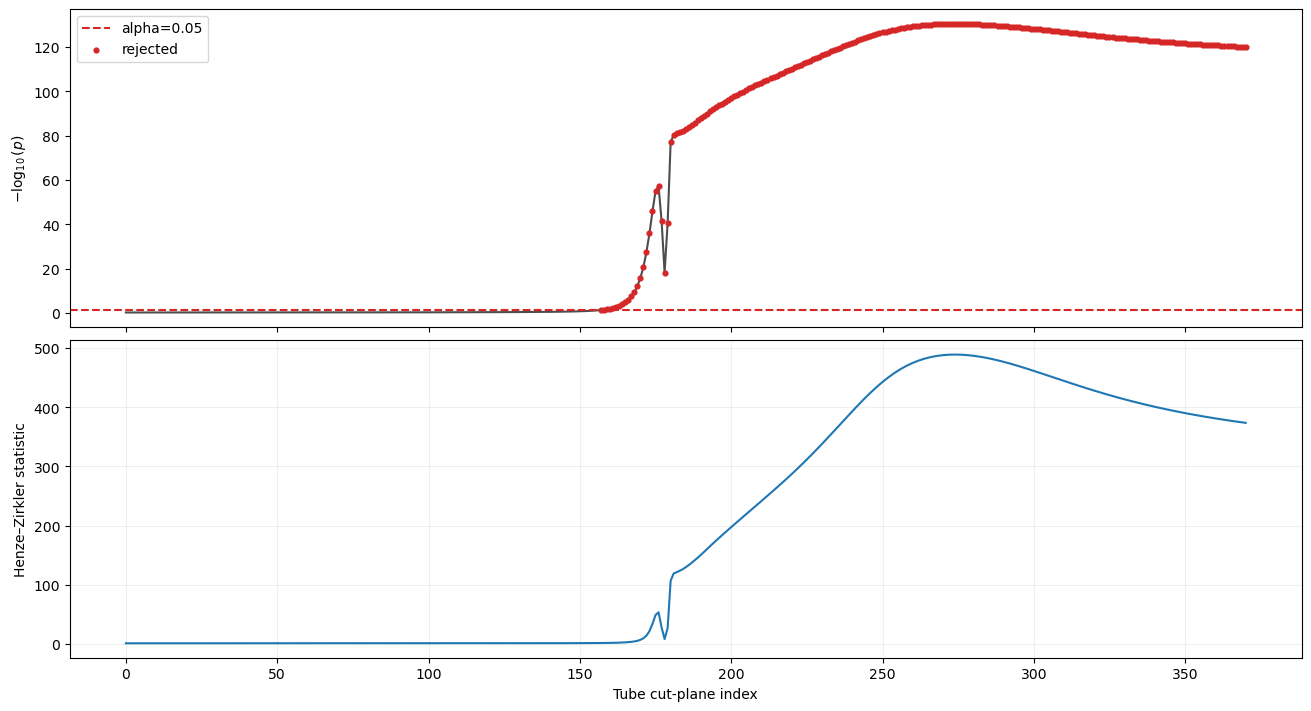

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True, constrained_layout=True)
tiny = np.finfo(float).tiny
axes[0].plot(normality.cutplane_index, -np.log10(normality.p_value.clip(lower=tiny)), color='0.3')
axes[0].axhline(-np.log10(ALPHA), color='tab:red', ls='--', label=f'alpha={ALPHA}')
axes[0].scatter(non_gaussian.cutplane_index, -np.log10(non_gaussian.p_value.clip(lower=tiny)),
                s=12, color='tab:red', label='rejected', zorder=3)
axes[0].set_ylabel(r'$-\log_{10}(p)$'); axes[0].legend()
axes[1].plot(normality.cutplane_index, normality.hz, color='tab:blue')
axes[1].set(xlabel='Tube cut-plane index', ylabel='Henze–Zirkler statistic')
axes[1].grid(alpha=.2)
plt.show()

## Plot rejected point clouds against the existing ellipse

The red ring is read from the current tube JSON and projected into the same local 2D frame as the variants.

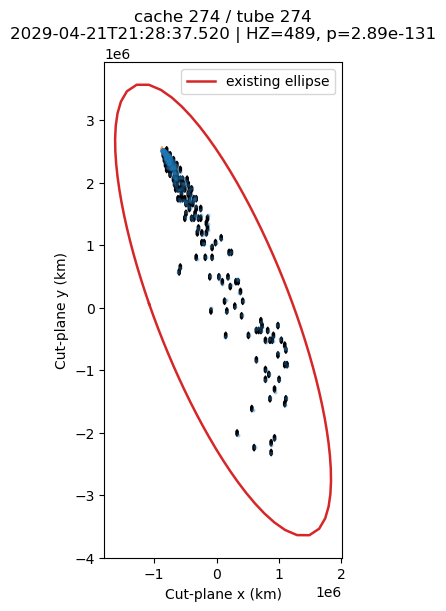

In [6]:
with TUBE_JSON.open('r', encoding='utf-8') as file:
    tube_data = json.load(file)

def existing_ring_2d(projected):
    polygon = tube_data['polygons'][projected['cutplane_index']]
    ring_3d_km = np.array([[p['x'], p['y'], p['z']] for p in polygon['points']]) / 1000.0
    # This ring was produced by the legacy normalized-coordinate pipeline and
    # is not guaranteed to lie exactly on the newly reconstructed physical plane.
    # Orthogonally project it for comparison without the legacy coplanarity warning.
    rotation = tube_util.calcRotationMatrix(projected['normal'], np.array([0.0, 0.0, 1.0]))
    centered = ring_3d_km - projected['cutplane'].center_km
    return (rotation @ centered.T).T[:, :2]

def plot_cutplane(cache_index, ax=None, density=False):
    projected = project_cache_row(int(cache_index))
    points, ring = projected['points_2d_km'], existing_ring_2d(projected)
    row = normality.iloc[int(cache_index)]
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
    if density:
        ax.hexbin(points[:, 0], points[:, 1], gridsize=55, mincnt=1, cmap='magma')
    ax.scatter(points[:, 0], points[:, 1], s=8, alpha=.38, linewidths=0)
    closed = np.vstack([ring, ring[0]])
    ax.plot(closed[:, 0], closed[:, 1], color='tab:red', lw=1.8, label='existing ellipse')
    ax.set_aspect('equal', adjustable='box')
    ax.set(xlabel='Cut-plane x (km)', ylabel='Cut-plane y (km)',
           title=f"cache {cache_index} / tube {projected['cutplane_index']}\n{row.time_utc} | HZ={row.hz:.3g}, p={row.p_value:.3g}")
    ax.legend()
    return projected

if len(non_gaussian):
    plot_cutplane(int(non_gaussian.sort_values('p_value').iloc[0].cache_index), density=True)
    plt.show()
else:
    print('No rejected cut planes at this ALPHA.')

## Gallery of strongest rejections

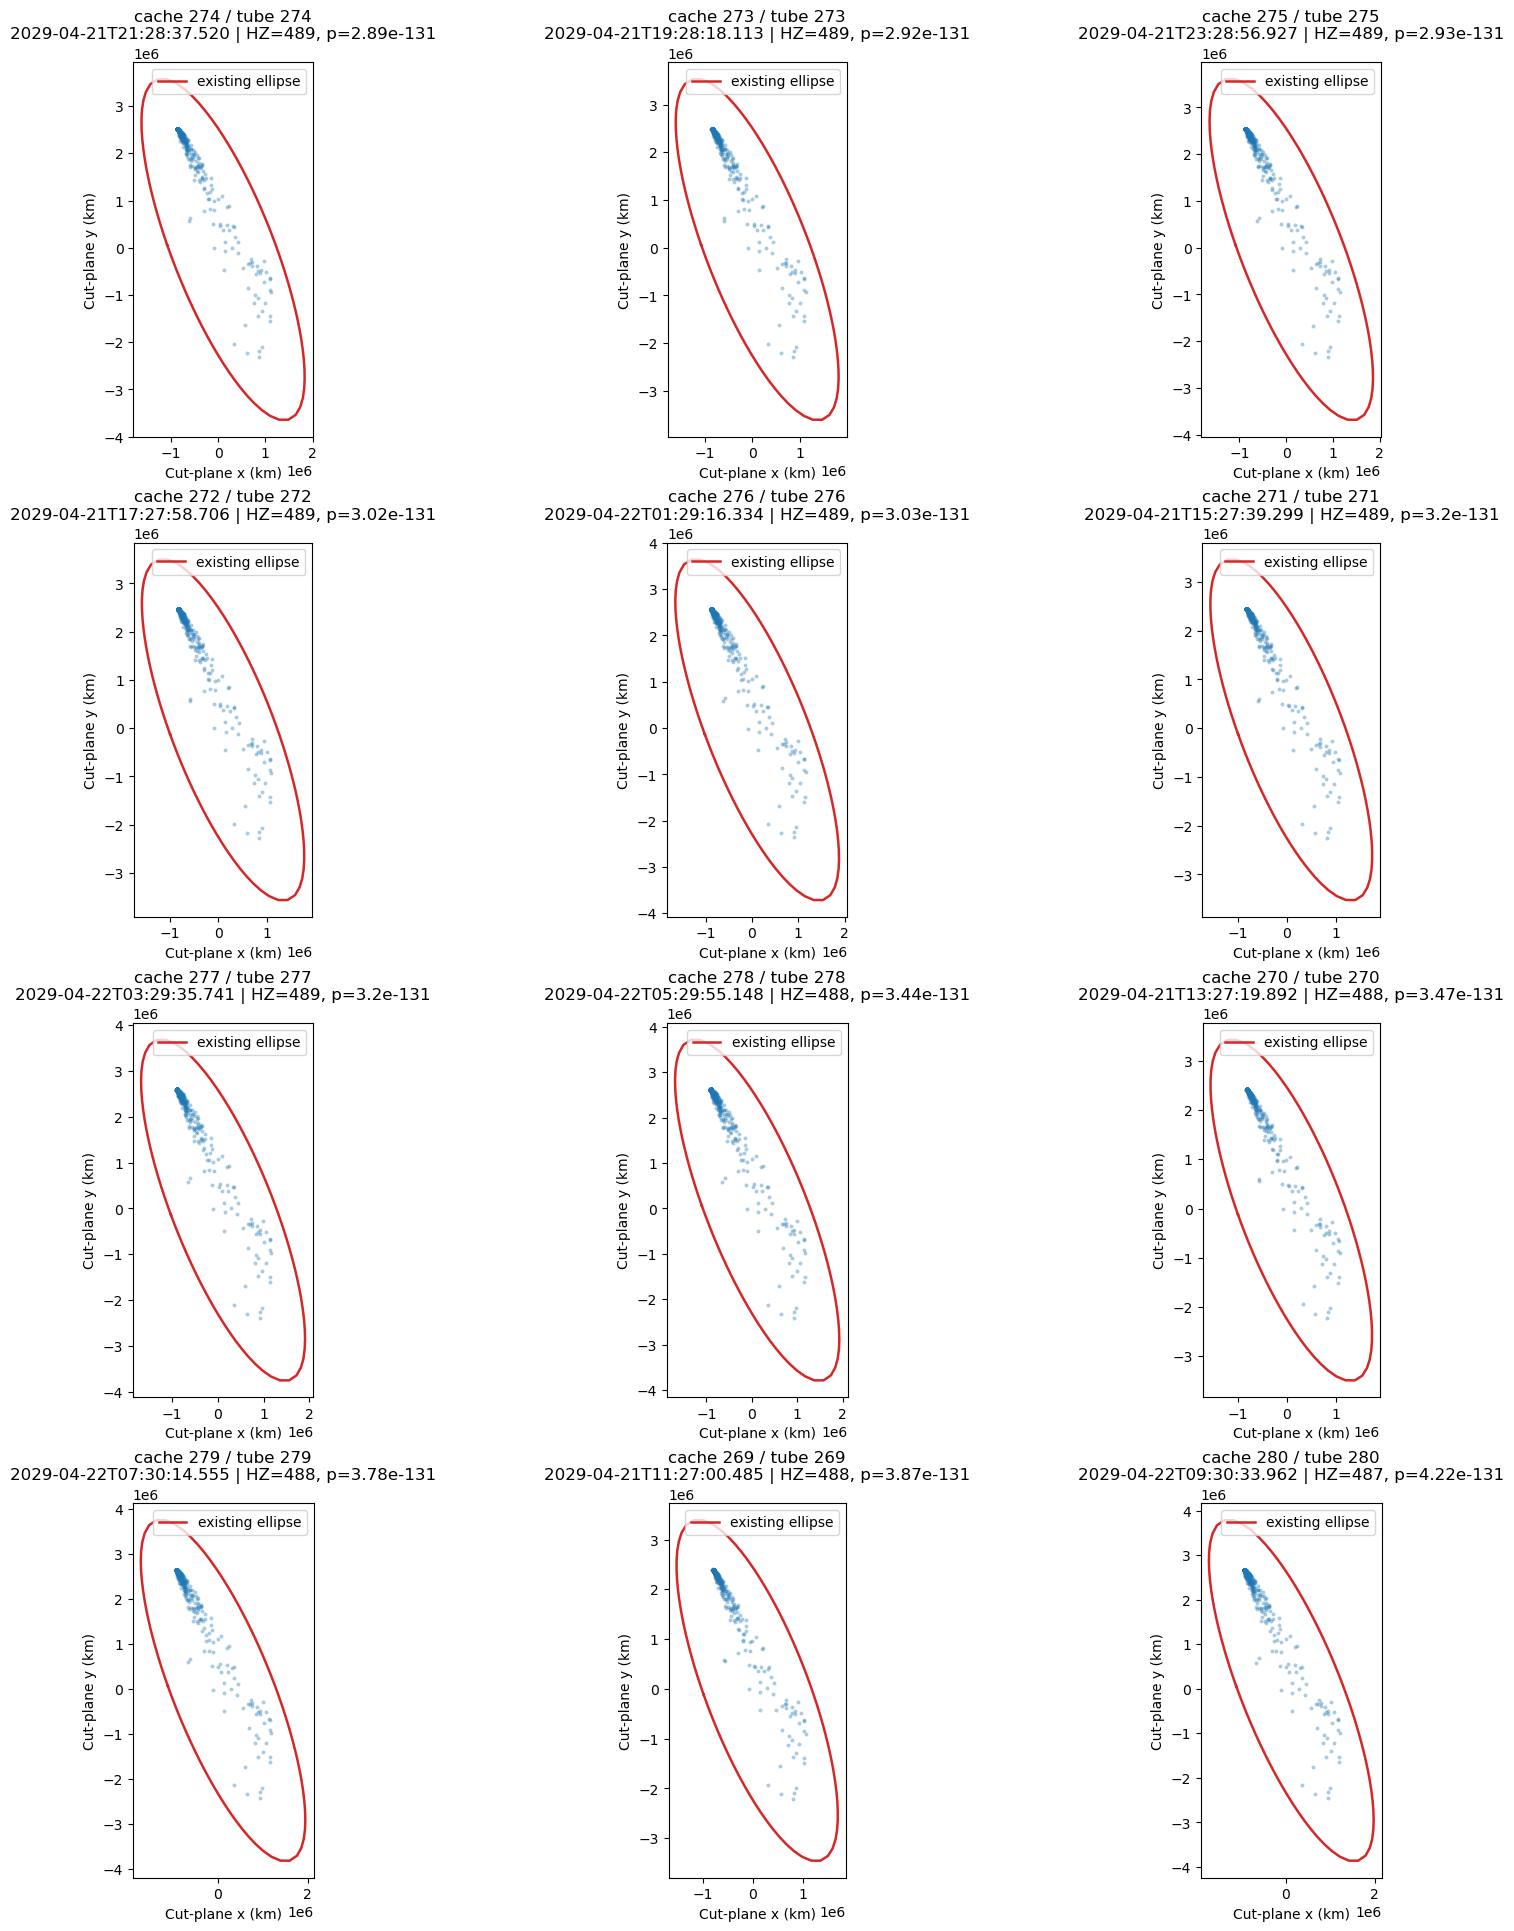

In [7]:
GALLERY_COUNT = 12
gallery = non_gaussian.sort_values('p_value').head(GALLERY_COUNT)
if len(gallery):
    cols, rows = 3, int(np.ceil(len(gallery) / 3))
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4.8*rows), constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()
    for ax, (_, row) in zip(axes, gallery.iterrows()):
        plot_cutplane(int(row.cache_index), ax=ax)
    for ax in axes[len(gallery):]: ax.set_visible(False)
    plt.show()
else:
    print('Nothing to plot.')

## Inspect one rejection and neighboring slices

Change `SELECTED_CACHE_INDEX` using the table or gallery. Neighbors show whether rejection persists or flickers for one slice.

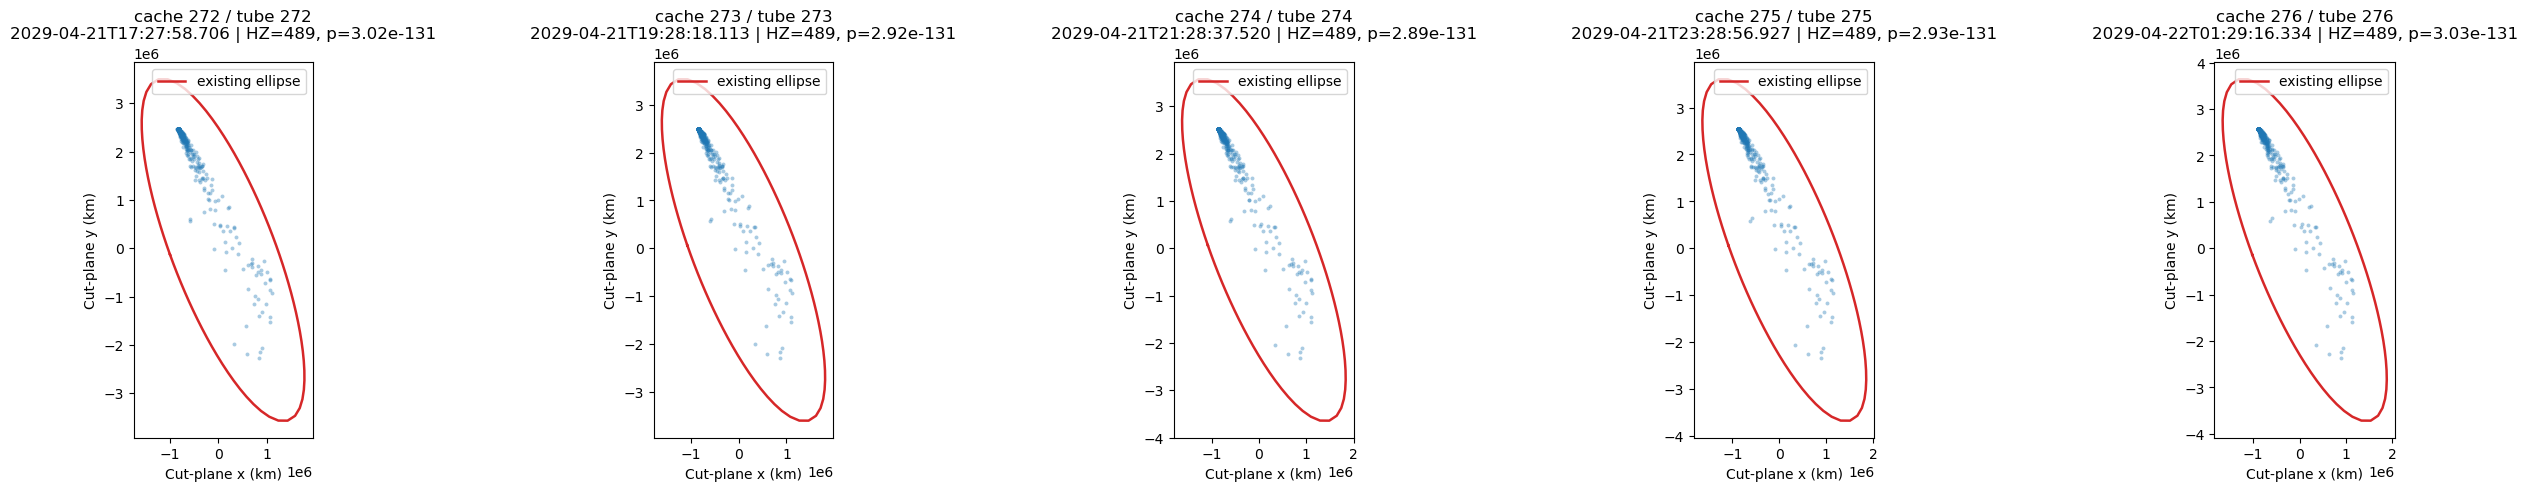

,cache_index,cutplane_index,time_utc,num_projected,hz,p_value,is_gaussian
272,272,272,2029-04-21T17:27:58.706,1000,489.158438,3.020318e-131,False
273,273,273,2029-04-21T19:28:18.113,1000,489.334852,2.922359e-131,False
274,274,274,2029-04-21T21:28:37.520,1000,489.387131,2.893950e-131,False
275,275,275,2029-04-21T23:28:56.927,1000,489.320393,2.930266e-131,False
276,276,276,2029-04-22T01:29:16.334,1000,489.139611,3.030966e-131,False


In [8]:
SELECTED_CACHE_INDEX = (int(non_gaussian.sort_values('p_value').iloc[0].cache_index)
                        if len(non_gaussian) else 0)
NEIGHBOR_RADIUS = 2
neighbors = list(range(max(0, SELECTED_CACHE_INDEX-NEIGHBOR_RADIUS),
                       min(len(normality), SELECTED_CACHE_INDEX+NEIGHBOR_RADIUS+1)))
fig, axes = plt.subplots(1, len(neighbors), figsize=(5.2*len(neighbors), 4.8), constrained_layout=True)
for ax, index in zip(np.atleast_1d(axes), neighbors):
    plot_cutplane(index, ax=ax)
plt.show()
display(normality.iloc[neighbors][['cache_index', 'cutplane_index', 'time_utc',
    'num_projected', 'hz', 'p_value', 'is_gaussian']])

## Ten consecutive alpha shapes from the first non-Gaussian cut plane

The sequence starts at the earliest rejected slice and includes the next nine chronological slices, whether or not those later slices pass the Gaussian test. Blue points are projected variants, red is the existing ellipse, and green is the alpha-shape boundary.

Starting at cache slice 180, tube cut plane 180


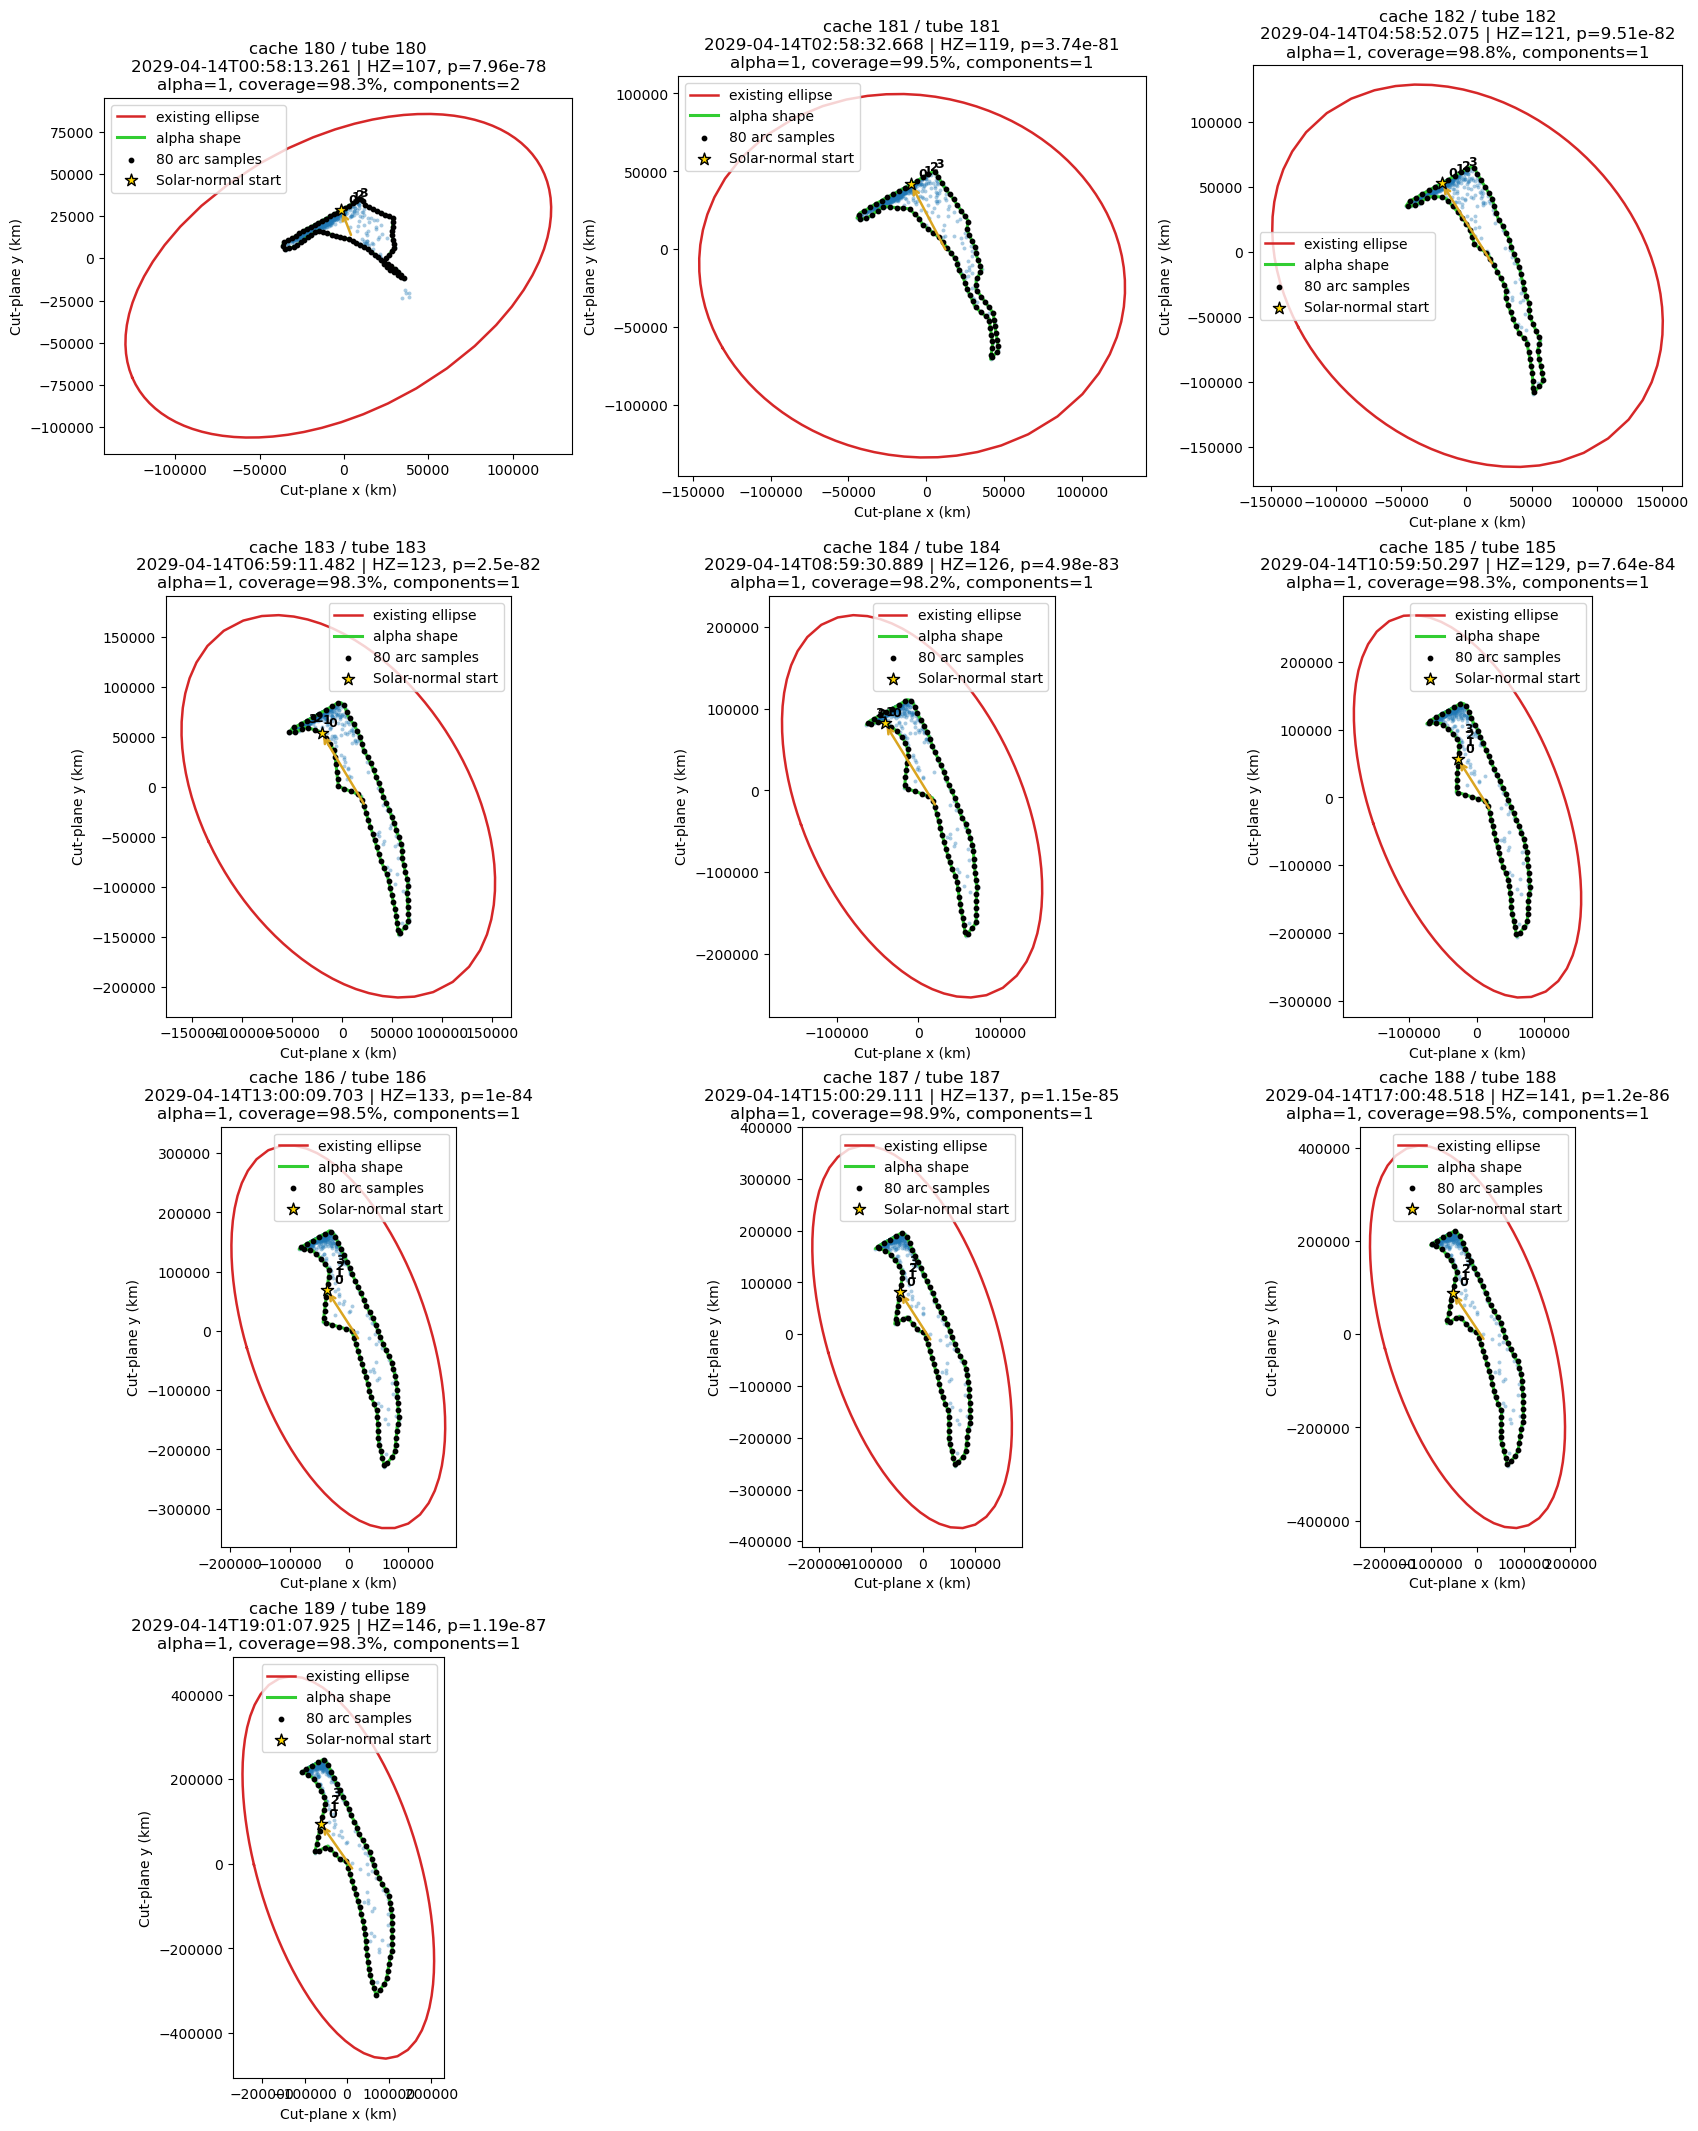

,cache_index,cutplane_index,time_utc,alpha_shape,coverage,component_count,boundary_vertices,sample_count,clockwise,convex_hull_fallback
0,180,180,2029-04-14T00:58:13.261,1.0,0.983,2,63,80,True,False
1,181,181,2029-04-14T02:58:32.668,1.0,0.995,1,67,80,True,False
2,182,182,2029-04-14T04:58:52.075,1.0,0.988,1,74,80,True,False
3,183,183,2029-04-14T06:59:11.482,1.0,0.983,1,76,80,True,False
4,184,184,2029-04-14T08:59:30.889,1.0,0.982,1,77,80,True,False
5,185,185,2029-04-14T10:59:50.297,1.0,0.983,1,73,80,True,False
6,186,186,2029-04-14T13:00:09.703,1.0,0.985,1,73,80,True,False
7,187,187,2029-04-14T15:00:29.111,1.0,0.989,1,69,80,True,False
8,188,188,2029-04-14T17:00:48.518,1.0,0.985,1,79,80,True,False
9,189,189,2029-04-14T19:01:07.925,1.0,0.983,1,78,80,True,False


In [9]:
import importlib
import tube_generation.polygon as polygon_generation
polygon_generation = importlib.reload(polygon_generation)
calculate_alpha_shape = polygon_generation.calculate_alpha_shape
sample_alpha_shape_boundary = polygon_generation.sample_alpha_shape_boundary

ALPHA_SHAPE = 1.0
NUMBER_TO_PLOT = 10
START_SLICE_INDEX = 180  # None = first non-Gaussian slice; otherwise use a cache-row index

if non_gaussian.empty:
    raise RuntimeError('No non-Gaussian cut planes are available to plot.')
first_non_gaussian_cache_index = int(
    non_gaussian.sort_values('cutplane_index').iloc[0].cache_index
)
start_index = (first_non_gaussian_cache_index
               if START_SLICE_INDEX is None else int(START_SLICE_INDEX))
if not 0 <= start_index < len(normality):
    raise IndexError(f'START_SLICE_INDEX must be between 0 and {len(normality) - 1}')
print(f'Starting at cache slice {start_index}, tube cut plane {int(cutplane_indices[start_index])}')
consecutive_indices = list(range(
    start_index,
    min(start_index + NUMBER_TO_PLOT, len(normality)),
))
selected_slices = normality.iloc[consecutive_indices]

columns = 3
rows = int(np.ceil(len(selected_slices) / columns))
fig, axes = plt.subplots(rows, columns, figsize=(17, 5.3 * rows), constrained_layout=True)
axes = np.atleast_1d(axes).ravel()
diagnostics = []

for ax, (_, row) in zip(axes, selected_slices.iterrows()):
    cache_index = int(row.cache_index)
    projected = plot_cutplane(cache_index, ax=ax)
    result = calculate_alpha_shape(projected['points_2d_km'], alpha=ALPHA_SHAPE)
    samples = sample_alpha_shape_boundary(result, 80, projected['normal'])
    boundary = np.vstack([result.boundary_2d, result.boundary_2d[0]])
    ax.plot(boundary[:, 0], boundary[:, 1], color='limegreen', lw=2.2, label='alpha shape')
    ax.scatter(samples[:, 0], samples[:, 1], s=10, color='black', zorder=4, label='80 arc samples')
    ax.scatter(samples[0, 0], samples[0, 1], s=85, marker='*', color='gold',
               edgecolor='black', zorder=5, label='Solar-normal start')
    ring_center = samples.mean(axis=0)
    ax.annotate('', xy=samples[0], xytext=ring_center,
                arrowprops=dict(arrowstyle='->', color='goldenrod', lw=1.8), zorder=4)
    for sample_index in range(min(4, len(samples))):
        ax.annotate(str(sample_index), samples[sample_index], xytext=(5, 5),
                    textcoords='offset points', fontsize=9, fontweight='bold', zorder=6)
    ax.set_title(
        ax.get_title() + f'\nalpha={ALPHA_SHAPE:g}, coverage={result.coverage:.1%}, components={result.component_count}'
    )
    ax.legend(loc='best')
    diagnostics.append({
        'cache_index': cache_index, 'cutplane_index': int(row.cutplane_index),
        'time_utc': row.time_utc, 'alpha_shape': ALPHA_SHAPE,
        'coverage': result.coverage, 'component_count': result.component_count,
        'boundary_vertices': len(result.boundary_2d),
        'sample_count': len(samples),
        'clockwise': bool(0.5 * np.sum(samples[:, 0] * np.roll(samples[:, 1], -1)
                                    - samples[:, 1] * np.roll(samples[:, 0], -1)) < 0),
        'convex_hull_fallback': result.used_convex_hull,
    })

for ax in axes[len(selected_slices):]:
    ax.set_visible(False)
plt.show()
display(pd.DataFrame(diagnostics))

## What to look for

- Is rejection caused by skewness, curvature, multiple groups, or isolated outliers?
- Do rejected slices form continuous time intervals?
- Does the ellipse enclose large visibly empty regions?
- Are there disconnected groups that would require multiple polygons?
- Does the conclusion remain stable when `ALPHA` changes?

These observations determine whether the first polygon prototype should use a convex hull, alpha shape, density contour, or clustering.

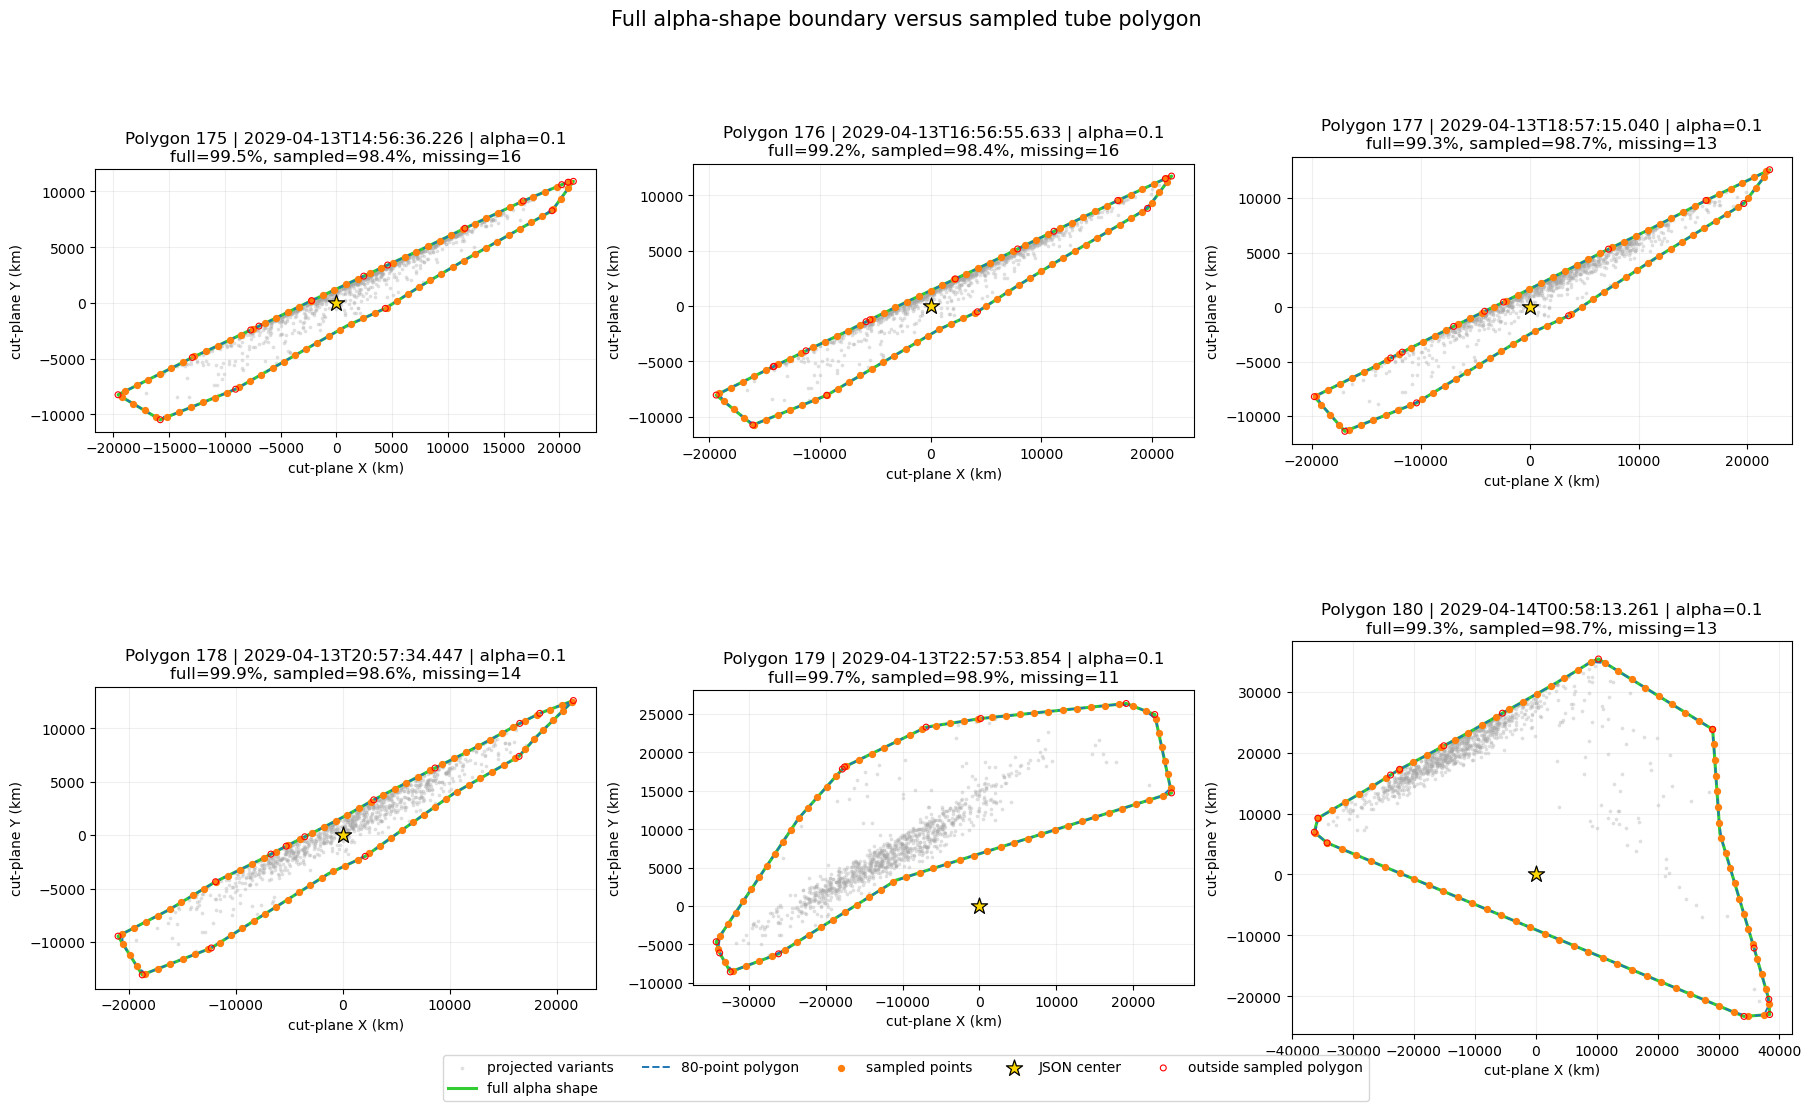

In [10]:
# Compare the full alpha shape with its 80-point sampled polygon.
# Inspect source polygon 358 and the following five slices (358-363).
INSPECT_START_POLYGON = 175
INSPECT_SLICE_COUNT = 6
INSPECT_ALPHA = 0.1
INSPECT_SAMPLE_COUNT = 80

import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import Point, Polygon
from shapely.prepared import prep

fig, axes = plt.subplots(2, 3, figsize=(18, 11), constrained_layout=True)
for axis, polygon_index in zip(
    axes.ravel(),
    range(INSPECT_START_POLYGON, INSPECT_START_POLYGON + INSPECT_SLICE_COUNT),
):
    cache_matches = np.flatnonzero(cutplane_indices == polygon_index)
    if len(cache_matches) != 1:
        raise ValueError(
            f'Expected one cache row for polygon {polygon_index}, found {len(cache_matches)}'
        )
    projected = project_cache_row(int(cache_matches[0]))
    points = projected['points_2d_km']
    json_center = tube_data['polygons'][polygon_index]['center']
    json_time = tube_data['polygons'][polygon_index]['time']
    json_center_km = np.array(
        [json_center['x'], json_center['y'], json_center['z']], dtype=float
    ) / 1000.0
    center_rotation = tube_util.calcRotationMatrix(
        projected['normal'], np.array([0.0, 0.0, 1.0])
    )
    json_center_2d = (
        center_rotation @ (json_center_km - projected['cutplane'].center_km)
    )[:2]
    result = calculate_alpha_shape(points, alpha=INSPECT_ALPHA)
    sampled = sample_alpha_shape_boundary(
        result, INSPECT_SAMPLE_COUNT, projected['normal']
    )
    alpha_closed = np.vstack([result.boundary_2d, result.boundary_2d[0]])
    sampled_closed = np.vstack([sampled, sampled[0]])
    polygon_span_km = float(np.ptp(sampled, axis=0).max())
    coverage_tolerance_km = max(
        polygon_span_km * polygon_generation.POLYGON_COVERAGE_RELATIVE_TOLERANCE,
        np.finfo(float).eps * max(1.0, polygon_span_km) * 32.0,
    )
    sampled_polygon = Polygon(sampled).buffer(coverage_tolerance_km)
    sampled_prepared = prep(sampled_polygon)
    sampled_covered = np.fromiter(
        (sampled_prepared.covers(Point(point)) for point in points),
        dtype=bool, count=len(points),
    )
    sampled_coverage = sampled_covered.mean()

    axis.scatter(points[:, 0], points[:, 1], s=7, color='0.65', alpha=0.35,
                 linewidths=0, label='projected variants')
    axis.plot(alpha_closed[:, 0], alpha_closed[:, 1], color='limegreen',
              linewidth=2.2, label='full alpha shape')
    axis.plot(sampled_closed[:, 0], sampled_closed[:, 1], color='tab:blue',
              linewidth=1.4, linestyle='--', label='80-point polygon')
    axis.scatter(sampled[:, 0], sampled[:, 1], s=18, color='tab:orange',
                 zorder=4, label='sampled points')
    axis.scatter(
        json_center_2d[0], json_center_2d[1], s=150, marker='*',
        facecolor='gold', edgecolor='black', linewidth=0.9, zorder=7,
        label='JSON center',
    )
    axis.scatter(points[~sampled_covered, 0], points[~sampled_covered, 1],
                 s=18, facecolors='none', edgecolors='red', linewidths=0.8,
                 zorder=5, label='outside sampled polygon')
    axis.set_title(
        f'Polygon {polygon_index} | {json_time} | alpha={INSPECT_ALPHA:g}\n'
        f'full={result.coverage:.1%}, sampled={sampled_coverage:.1%}, '
        f'missing={np.count_nonzero(~sampled_covered)}'
    )
    axis.set_xlabel('cut-plane X (km)')
    axis.set_ylabel('cut-plane Y (km)')
    axis.set_aspect('equal', adjustable='box')
    axis.grid(alpha=0.2)

handles, labels = axes.ravel()[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5)
fig.suptitle('Full alpha-shape boundary versus sampled tube polygon', fontsize=15)
plt.show()


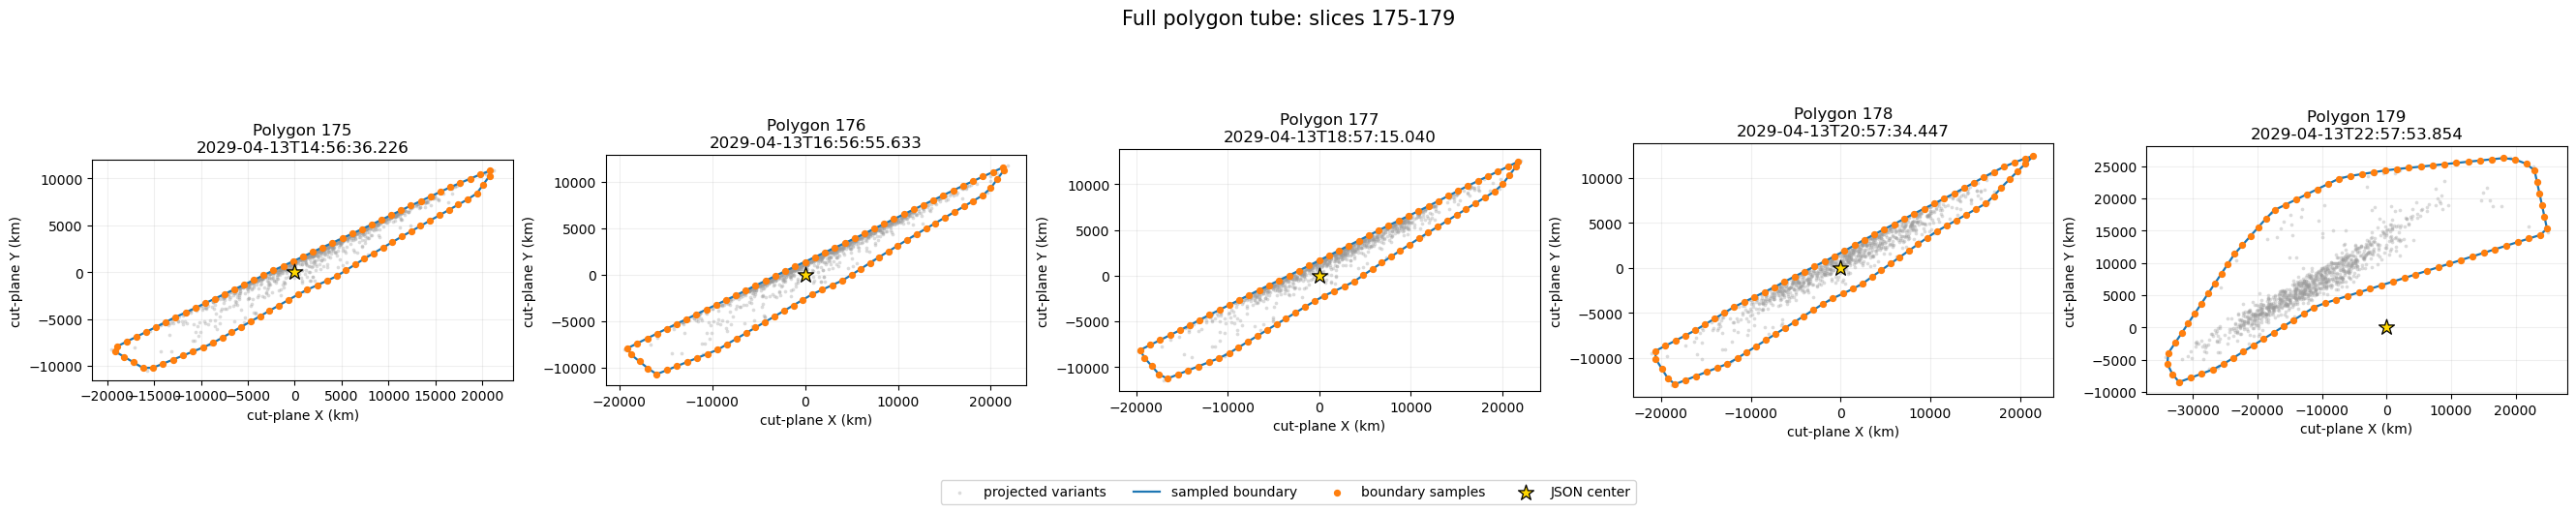

In [11]:
# Plot projected variant slices and the sampled boundaries stored in the full tube.
# Change FULL_TUBE_START to select the first source polygon.
FULL_TUBE_START = 175
FULL_TUBE_SLICE_COUNT = 5

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

start = Path.cwd().resolve()
repo_root = next(
    (path for path in [start, *start.parents]
     if (path / 'data' / 'B612_data' / 'Test' / '2004 MN4').is_dir()),
    None,
)
if repo_root is None:
    raise RuntimeError('Could not find the NEOviz repository root')

full_tube_path = (
    repo_root / 'data' / 'B612_data' / 'Test' / '2004 MN4'
    / 'tube_2004_MN4_polygon_all.json'
)
with full_tube_path.open('r', encoding='utf-8') as file:
    full_tube = json.load(file)
full_polygons = full_tube['polygons']

if not isinstance(FULL_TUBE_START, int) or not isinstance(FULL_TUBE_SLICE_COUNT, int):
    raise TypeError('FULL_TUBE_START and FULL_TUBE_SLICE_COUNT must be integers')
if FULL_TUBE_SLICE_COUNT < 1:
    raise ValueError('FULL_TUBE_SLICE_COUNT must be positive')
if not 0 <= FULL_TUBE_START <= len(full_polygons) - FULL_TUBE_SLICE_COUNT:
    raise IndexError(
        f'FULL_TUBE_START must be between 0 and '
        f'{len(full_polygons) - FULL_TUBE_SLICE_COUNT}'
    )

fig, axes = plt.subplots(
    1, FULL_TUBE_SLICE_COUNT,
    figsize=(5.3 * FULL_TUBE_SLICE_COUNT, 5.2),
    constrained_layout=True, squeeze=False,
)

for axis, polygon_index in zip(
    axes.ravel(),
    range(FULL_TUBE_START, FULL_TUBE_START + FULL_TUBE_SLICE_COUNT),
):
    cache_matches = np.flatnonzero(cutplane_indices == polygon_index)
    if len(cache_matches) != 1:
        raise ValueError(
            f'Expected one cache row for polygon {polygon_index}, found {len(cache_matches)}'
        )
    projected = project_cache_row(int(cache_matches[0]))
    variants_2d_km = projected['points_2d_km']
    polygon = full_polygons[polygon_index]
    center = polygon['center']
    center_km = np.array([center['x'], center['y'], center['z']], dtype=float) / 1000.0
    boundary_3d_km = np.array(
        [[point['x'], point['y'], point['z']] for point in polygon['points']],
        dtype=float,
    ) / 1000.0
    rotation = tube_util.calcRotationMatrix(
        projected['normal'], np.array([0.0, 0.0, 1.0])
    )
    sampled_2d_km = (rotation @ (boundary_3d_km - center_km).T).T[:, :2]
    sampled_closed = np.vstack([sampled_2d_km, sampled_2d_km[0]])

    axis.scatter(
        variants_2d_km[:, 0], variants_2d_km[:, 1],
        s=7, color='0.6', alpha=0.35, linewidths=0, label='projected variants',
    )
    axis.plot(
        sampled_closed[:, 0], sampled_closed[:, 1],
        color='tab:blue', linewidth=1.6, label='sampled boundary',
    )
    axis.scatter(
        sampled_2d_km[:, 0], sampled_2d_km[:, 1],
        s=18, color='tab:orange', zorder=4, label='boundary samples',
    )
    axis.scatter(
        0.0, 0.0, s=145, marker='*', facecolor='gold', edgecolor='black',
        linewidth=0.9, zorder=6, label='JSON center',
    )
    axis.set_title(f'Polygon {polygon_index}\n{polygon["time"]}')
    axis.set_xlabel('cut-plane X (km)')
    axis.set_ylabel('cut-plane Y (km)')
    axis.set_aspect('equal', adjustable='box')
    axis.grid(alpha=0.2)

handles, labels = axes.ravel()[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4)
fig.suptitle(
    f'Full polygon tube: slices {FULL_TUBE_START}-'
    f'{FULL_TUBE_START + FULL_TUBE_SLICE_COUNT - 1}',
    fontsize=15,
)
plt.show()


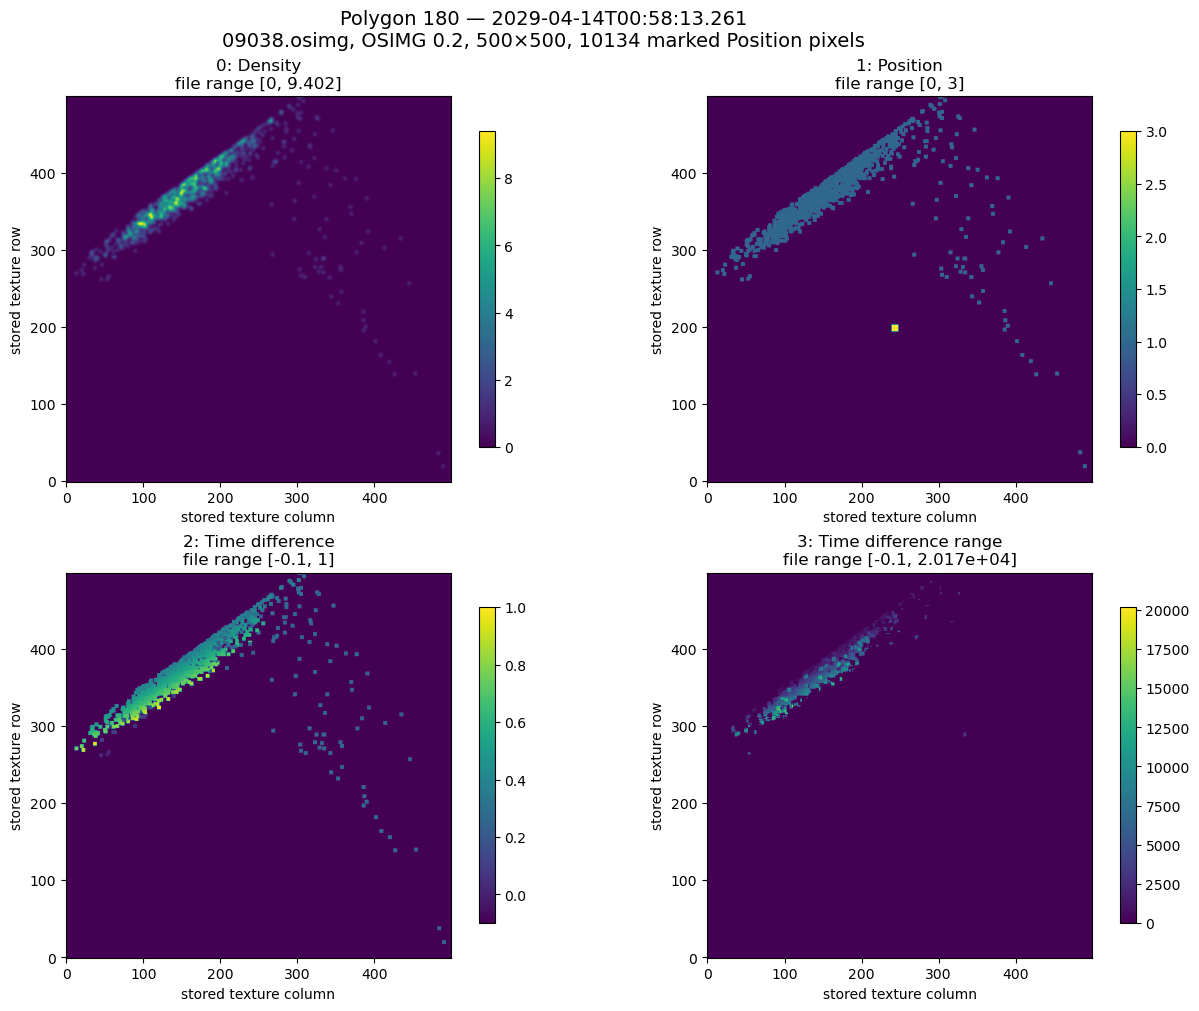

Tube: /mnt/c/Users/flan/Documents/NEOviz/NEOviz_repo/data/B612_data/Test/2004 MN4/tube_2004_MN4_polygon_all.json
Texture: /mnt/c/Users/flan/Documents/NEOviz/NEOviz_repo/data/B612_data/Test/2004 MN4/textures_polygon_all/09038.osimg


In [12]:
# Inspect the raw OpenSpace texture for one polygon.
# Change this index to inspect another polygon from the full tube.
TEXTURE_POLYGON_INDEX = 180

from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

def find_from_notebook(*relative_candidates):
    for relative in relative_candidates:
        for base in (Path.cwd(), Path.cwd().parent):
            candidate = (base / relative).resolve()
            if candidate.exists():
                return candidate
    raise FileNotFoundError(f'Could not find any of: {relative_candidates}')

tube_path = find_from_notebook(
    Path('data/B612_data/Test/2004 MN4/tube_2004_MN4_polygon_all.json'),
)
texture_dir = find_from_notebook(
    Path('data/B612_data/Test/2004 MN4/textures_polygon_all'),
)

with tube_path.open('r', encoding='utf-8') as file:
    texture_tube = json.load(file)
polygon_record = texture_tube['polygons'][TEXTURE_POLYGON_INDEX]
texture_path = texture_dir / polygon_record['texture']

def read_osimg(path):
    with Path(path).open('rb') as file:
        version = tuple(np.frombuffer(file.read(2), dtype=np.uint8))
        width, height = np.frombuffer(file.read(8), dtype='<u4')
        channels = int(np.frombuffer(file.read(1), dtype=np.uint8)[0])
        minimum = np.frombuffer(file.read(4 * channels), dtype='<f4')
        maximum = np.frombuffer(file.read(4 * channels), dtype='<f4')
        pixels = np.frombuffer(file.read(), dtype='<f4')
    expected = int(width * height * channels)
    if pixels.size != expected:
        raise ValueError(f'{path}: expected {expected} values, found {pixels.size}')
    return version, pixels.reshape(int(height), int(width), channels), minimum, maximum

version, texture_data, channel_min, channel_max = read_osimg(texture_path)
channel_names = texture_tube.get(
    'texture-channels',
    ['Density', 'Position', 'Time difference', 'Time difference range'],
)

fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)
for channel, axis in enumerate(axes.flat):
    image = axis.imshow(texture_data[:, :, channel], origin='lower', cmap='viridis')
    axis.set_title(
        f'{channel}: {channel_names[channel]}\n'
        f'file range [{channel_min[channel]:.4g}, {channel_max[channel]:.4g}]'
    )
    axis.set_xlabel('stored texture column')
    axis.set_ylabel('stored texture row')
    fig.colorbar(image, ax=axis, shrink=0.82)

position_pixels = np.count_nonzero(texture_data[:, :, 1] > 0.5)
fig.suptitle(
    f'Polygon {TEXTURE_POLYGON_INDEX} — {polygon_record["time"]}\n'
    f'{texture_path.name}, OSIMG {version[0]}.{version[1]}, '
    f'{texture_data.shape[1]}×{texture_data.shape[0]}, '
    f'{position_pixels} marked Position pixels',
    fontsize=14,
)
plt.show()
print('Tube:', tube_path)
print('Texture:', texture_path)


In [13]:
# Interactive fitted-MVEE inspection. Change i to select the starting slice.
i = 175
SLICE_COUNT = 5

import json
from pathlib import Path

import numpy as np
import plotly.graph_objects as go
import plotly.io as pio

from density_tube_generation.pipeline import (
    intersect_variants_with_plane,
    project_to_plane_2d,
)
from tube_generation import util as tube_util

repo_root = next(
    (path for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
     if (path / 'data' / 'B612_data' / 'Test' / '2004 MN4').is_dir()),
    None,
)
if repo_root is None:
    raise RuntimeError('Could not find the NEOviz repository root')

ellipse_path = (
    repo_root / 'data' / 'B612_data' / 'Test' / '2004 MN4'
    / 'tube_2004_MN4_ellipse.json'
)
cache_path = repo_root / 'revision' / 'cache' / '2004_MN4_cutplane_states.npz'

with ellipse_path.open('r', encoding='utf-8') as file:
    ellipse_polygons = json.load(file)['polygons']
with np.load(cache_path, allow_pickle=False) as cache:
    ellipse_cutplane_indices = cache['cutplane_indices'].copy()
    ellipse_positions_km = cache['positions_km'].copy()
    ellipse_velocities_km_s = cache['velocities_km_s'].copy()

if not isinstance(i, int):
    raise TypeError('i must be an integer')
if not 0 <= i <= len(ellipse_polygons) - SLICE_COUNT:
    raise IndexError(f'i must be between 0 and {len(ellipse_polygons) - SLICE_COUNT}')
pio.renderers.default = 'notebook_connected'

for polygon_index in range(i, i + SLICE_COUNT):
    polygon = ellipse_polygons[polygon_index]
    if 'bfo-center' not in polygon:
        raise KeyError(
            f'Polygon {polygon_index} has no bfo-center; regenerate the ellipse tube'
        )

    cache_matches = np.flatnonzero(ellipse_cutplane_indices == polygon_index)
    if len(cache_matches) != 1:
        raise ValueError(
            f'Expected one cache row for polygon {polygon_index}, found {len(cache_matches)}'
        )
    cache_index = int(cache_matches[0])
    positions = ellipse_positions_km[cache_index]
    velocities = ellipse_velocities_km_s[cache_index]
    finite_states = (
        np.all(np.isfinite(positions), axis=1)
        & np.all(np.isfinite(velocities), axis=1)
    )
    variant_indices = np.flatnonzero(finite_states)

    bfo_data = polygon['bfo-center']
    bfo_center_km = np.array(
        [bfo_data['x'], bfo_data['y'], bfo_data['z']], dtype=float
    ) / 1000.0
    fitted_data = polygon['center']
    fitted_center_km = np.array(
        [fitted_data['x'], fitted_data['y'], fitted_data['z']], dtype=float
    ) / 1000.0

    intersections_km, _, normal = intersect_variants_with_plane(
        bfo_center_km, positions[finite_states], velocities[finite_states]
    )
    variants_2d_km, intersection_valid = project_to_plane_2d(
        intersections_km, bfo_center_km, normal
    )
    variant_indices = variant_indices[intersection_valid]

    rotation = tube_util.calcRotationMatrix(
        normal, np.array([0.0, 0.0, 1.0])
    )
    boundary_3d_km = np.array(
        [[point['x'], point['y'], point['z']] for point in polygon['points']],
        dtype=float,
    ) / 1000.0
    boundary_2d_km = (
        rotation @ (boundary_3d_km - bfo_center_km).T
    ).T[:, :2]
    fitted_center_2d_km = (rotation @ (fitted_center_km - bfo_center_km))[:2]
    closed_boundary = np.vstack([boundary_2d_km, boundary_2d_km[0]])
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=variants_2d_km[:, 0], y=variants_2d_km[:, 1], mode='markers',
        name='variant intersections', customdata=variant_indices,
        marker={'size': 4, 'color': 'rgba(90,90,90,0.35)'},
        hovertemplate='variant %{customdata}<br>x=%{x:.3f} km<br>y=%{y:.3f} km<extra></extra>',
    ))
    fig.add_trace(go.Scatter(
        x=closed_boundary[:, 0], y=closed_boundary[:, 1], mode='lines+markers',
        name='fitted MVEE',
        line={'width': 2.5, 'color': '#2474B5'},
        marker={'size': 4, 'color': '#F26B21'},
        hovertemplate='x=%{x:.3f} km<br>y=%{y:.3f} km<extra>fitted MVEE</extra>',
    ))
    fig.add_trace(go.Scatter(
        x=[fitted_center_2d_km[0]], y=[fitted_center_2d_km[1]],
        mode='markers', name='fitted center',
        marker={'size': 15, 'symbol': 'star', 'color': 'gold',
                'line': {'width': 1.2, 'color': 'black'}},
        hovertemplate='x=%{x:.3f} km<br>y=%{y:.3f} km<extra>fitted center</extra>',
    ))
    fig.add_trace(go.Scatter(
        x=[0.0], y=[0.0], mode='markers', name='BFO center',
        marker={'size': 13, 'symbol': 'x', 'color': 'crimson',
                'line': {'width': 2, 'color': 'crimson'}},
        hovertemplate='x=0 km<br>y=0 km<extra>BFO center</extra>',
    ))
    fig.update_layout(
        title=(
            f'Fitted MVEE - slice {polygon_index} - {polygon["time"]}<br>'
            f'<sup>{len(variants_2d_km)} projected variants; coordinates relative to BFO</sup>'
        ),
        width=760, height=680,
        xaxis={'title': 'cut-plane X (km)', 'constrain': 'domain'},
        yaxis={'title': 'cut-plane Y (km)', 'scaleanchor': 'x', 'scaleratio': 1},
        legend={'orientation': 'h', 'y': -0.14},
        margin={'l': 70, 'r': 30, 't': 85, 'b': 100},
        template='plotly_white',
    )
    fig.show(config={'scrollZoom': True, 'displaylogo': False})


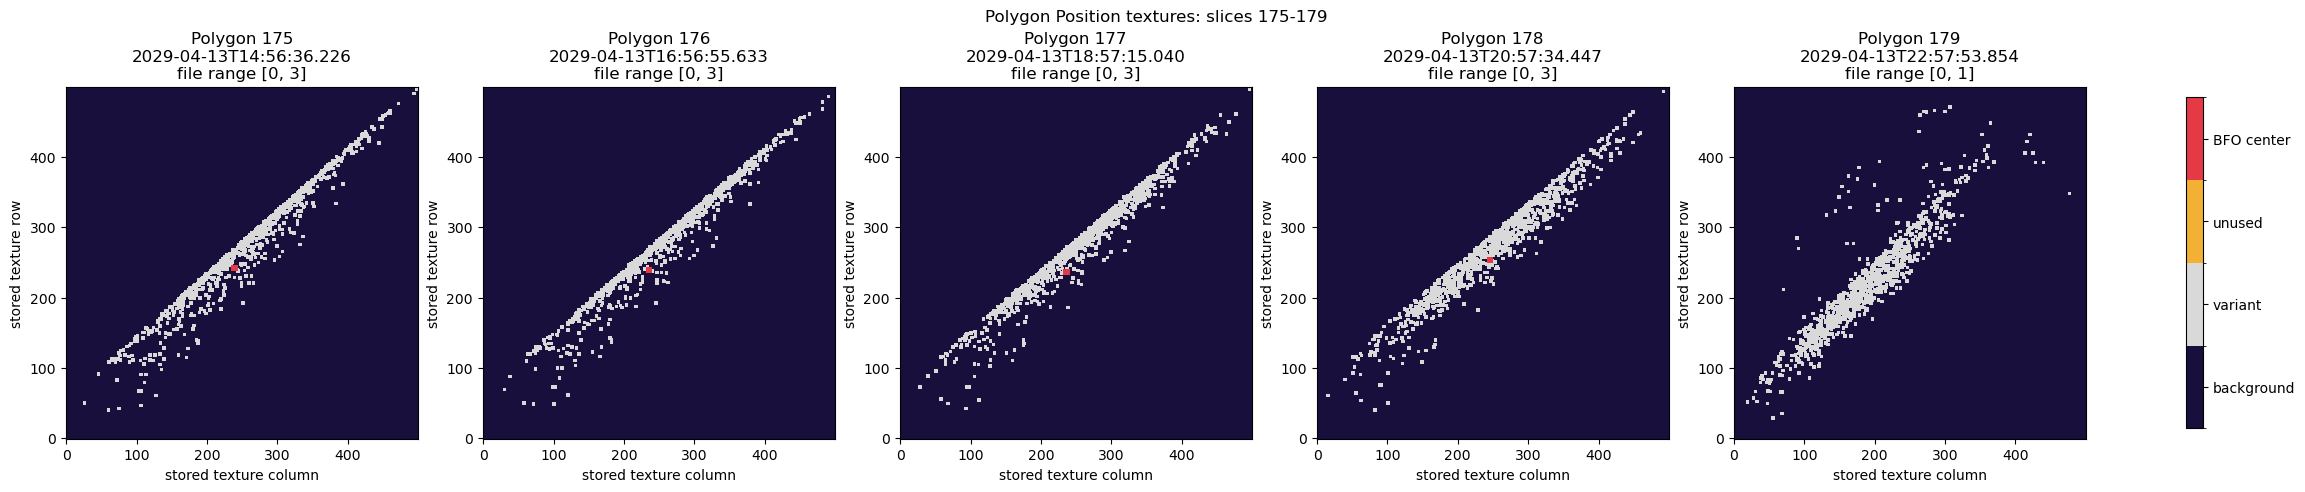

In [14]:
# Plot five consecutive polygon Position textures. Change i only.
i = 175
SLICE_COUNT = 5

import json
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
import numpy as np

repo_root = next(
    (path for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
     if (path / 'data' / 'B612_data' / 'Test' / '2004 MN4').is_dir()),
    None,
)
if repo_root is None:
    raise RuntimeError('Could not find the NEOviz repository root')

object_directory = repo_root / 'data' / 'B612_data' / 'Test' / '2004 MN4'
tube_path = object_directory / 'tube_2004_MN4_polygon_all.json'
texture_directory = object_directory / 'textures_polygon_all'

with tube_path.open('r', encoding='utf-8') as file:
    polygons = json.load(file)['polygons']
if not isinstance(i, int) or not 0 <= i <= len(polygons) - SLICE_COUNT:
    raise IndexError(f'i must be between 0 and {len(polygons) - SLICE_COUNT}')

def read_position_channel(path):
    with Path(path).open('rb') as file:
        file.read(2)  # OSIMG version
        width, height = np.fromfile(file, dtype='<u4', count=2)
        channels = int(np.fromfile(file, dtype=np.uint8, count=1)[0])
        minimum = np.fromfile(file, dtype='<f4', count=channels)
        maximum = np.fromfile(file, dtype='<f4', count=channels)
        pixels = np.fromfile(file, dtype='<f4')
    expected = int(width * height * channels)
    if channels < 2 or pixels.size != expected:
        raise ValueError(f'{path}: invalid OSIMG dimensions or channel count')
    image = pixels.reshape(int(height), int(width), channels)[:, :, 1]
    return image, float(minimum[1]), float(maximum[1])

position_cmap = ListedColormap(['#180F3D', '#D9D9D9', '#F2B134', '#E63946'])
position_norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], position_cmap.N)
fig, axes = plt.subplots(
    1, SLICE_COUNT, figsize=(4.6 * SLICE_COUNT, 4.8),
    constrained_layout=True, squeeze=False,
)
images = []
for axis, polygon_index in zip(axes.ravel(), range(i, i + SLICE_COUNT)):
    polygon = polygons[polygon_index]
    position, stored_minimum, stored_maximum = read_position_channel(
        texture_directory / polygon['texture']
    )
    images.append(axis.imshow(
        position, origin='lower', interpolation='nearest',
        cmap=position_cmap, norm=position_norm,
    ))
    axis.set_title(
        f'Polygon {polygon_index}\n{polygon["time"]}\n'
        f'file range [{stored_minimum:g}, {stored_maximum:g}]'
    )
    axis.set_xlabel('stored texture column')
    axis.set_ylabel('stored texture row')

colorbar = fig.colorbar(
    images[0], ax=axes.ravel().tolist(), ticks=[0, 1, 2, 3], shrink=0.78,
)
colorbar.ax.set_yticklabels(['background', 'variant', 'unused', 'BFO center'])
fig.suptitle(f'Polygon Position textures: slices {i}-{i + SLICE_COUNT - 1}')
plt.show()


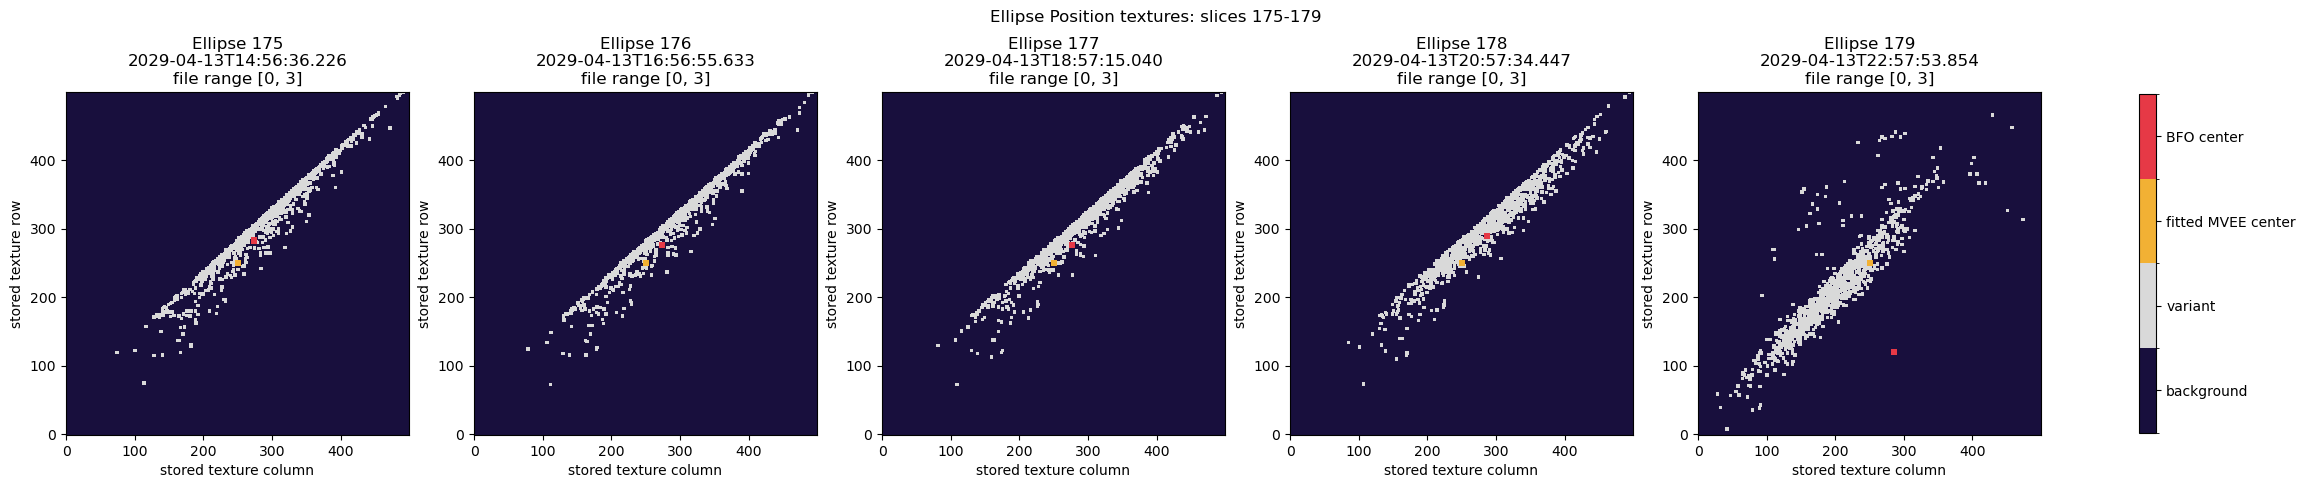

In [15]:
# Plot five consecutive fitted-ellipse Position textures. Change i only.
i = 175
SLICE_COUNT = 5

import json
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
import numpy as np

repo_root = next(
    (path for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
     if (path / 'data' / 'B612_data' / 'Test' / '2004 MN4').is_dir()),
    None,
)
if repo_root is None:
    raise RuntimeError('Could not find the NEOviz repository root')

object_directory = repo_root / 'data' / 'B612_data' / 'Test' / '2004 MN4'
tube_path = object_directory / 'tube_2004_MN4_ellipse.json'
texture_directory = object_directory / 'textures_ellipse'

with tube_path.open('r', encoding='utf-8') as file:
    polygons = json.load(file)['polygons']
if not isinstance(i, int) or not 0 <= i <= len(polygons) - SLICE_COUNT:
    raise IndexError(f'i must be between 0 and {len(polygons) - SLICE_COUNT}')

def read_position_channel(path):
    with Path(path).open('rb') as file:
        file.read(2)  # OSIMG version
        width, height = np.fromfile(file, dtype='<u4', count=2)
        channels = int(np.fromfile(file, dtype=np.uint8, count=1)[0])
        minimum = np.fromfile(file, dtype='<f4', count=channels)
        maximum = np.fromfile(file, dtype='<f4', count=channels)
        pixels = np.fromfile(file, dtype='<f4')
    expected = int(width * height * channels)
    if channels < 2 or pixels.size != expected:
        raise ValueError(f'{path}: invalid OSIMG dimensions or channel count')
    image = pixels.reshape(int(height), int(width), channels)[:, :, 1]
    return image, float(minimum[1]), float(maximum[1])

position_cmap = ListedColormap(['#180F3D', '#D9D9D9', '#F2B134', '#E63946'])
position_norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], position_cmap.N)
fig, axes = plt.subplots(
    1, SLICE_COUNT, figsize=(4.6 * SLICE_COUNT, 4.8),
    constrained_layout=True, squeeze=False,
)
images = []
for axis, polygon_index in zip(axes.ravel(), range(i, i + SLICE_COUNT)):
    polygon = polygons[polygon_index]
    position, stored_minimum, stored_maximum = read_position_channel(
        texture_directory / polygon['texture']
    )
    images.append(axis.imshow(
        position, origin='lower', interpolation='nearest',
        cmap=position_cmap, norm=position_norm,
    ))
    axis.set_title(
        f'Ellipse {polygon_index}\n{polygon["time"]}\n'
        f'file range [{stored_minimum:g}, {stored_maximum:g}]'
    )
    axis.set_xlabel('stored texture column')
    axis.set_ylabel('stored texture row')

colorbar = fig.colorbar(
    images[0], ax=axes.ravel().tolist(), ticks=[0, 1, 2, 3], shrink=0.78,
)
colorbar.ax.set_yticklabels(
    ['background', 'variant', 'fitted MVEE center', 'BFO center']
)
fig.suptitle(f'Ellipse Position textures: slices {i}-{i + SLICE_COUNT - 1}')
plt.show()


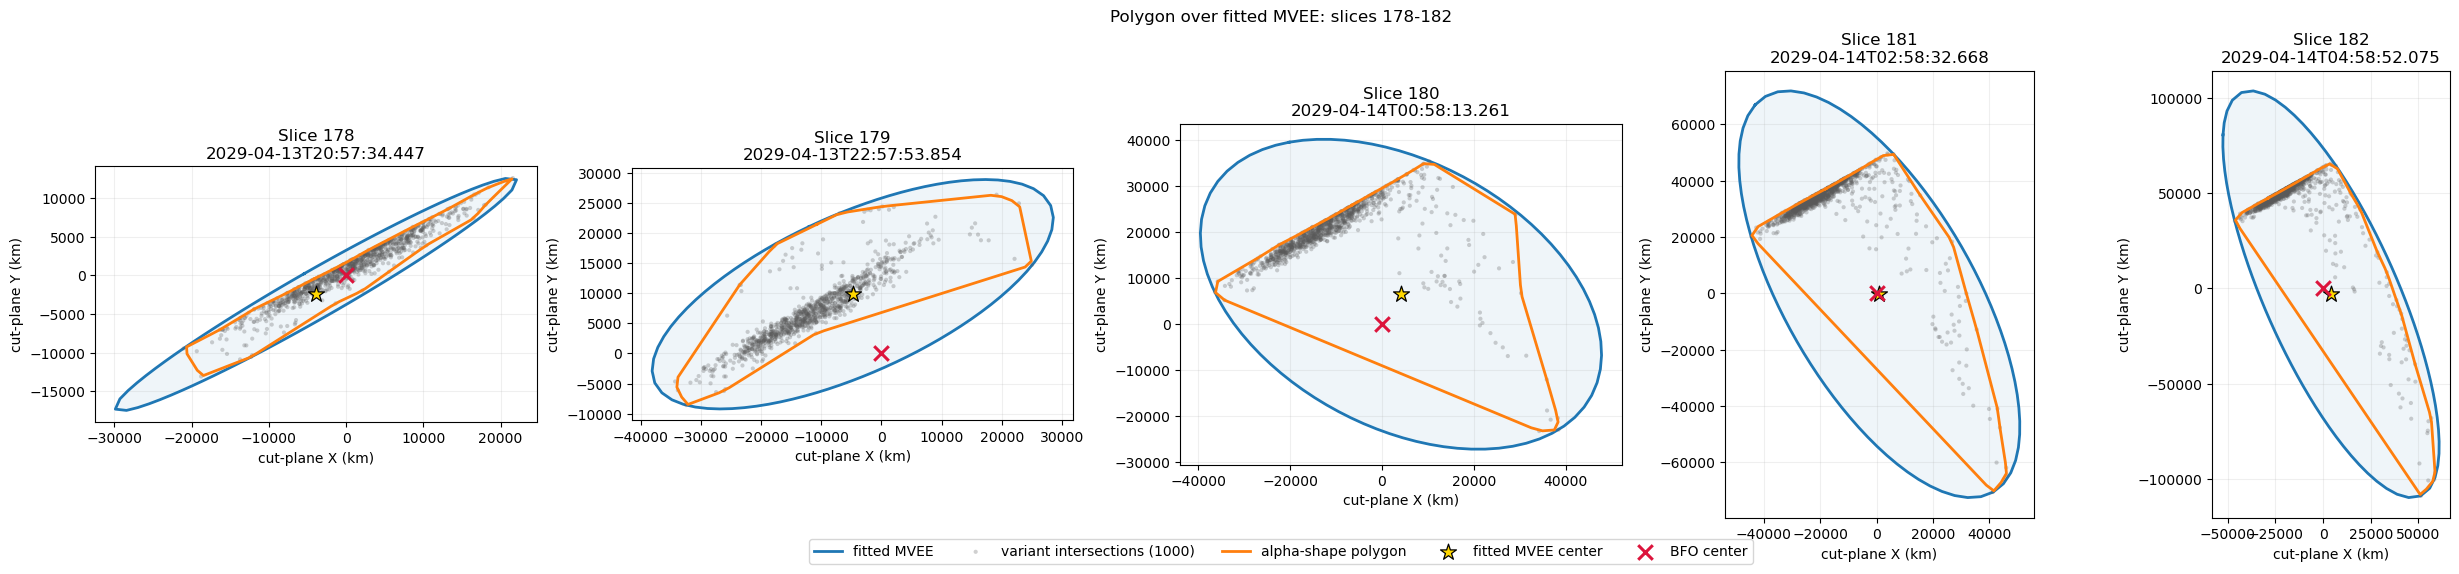

In [16]:
# Overlay five consecutive polygon slices on their fitted MVEEs. Change i only.
i = 178
SLICE_COUNT = 5

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from density_tube_generation.pipeline import intersect_variants_with_plane
from tube_generation import util as tube_util

repo_root = next(
    (path for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
     if (path / 'data' / 'B612_data' / 'Test' / '2004 MN4').is_dir()),
    None,
)
if repo_root is None:
    raise RuntimeError('Could not find the NEOviz repository root')

object_directory = repo_root / 'data' / 'B612_data' / 'Test' / '2004 MN4'
ellipse_path = object_directory / 'tube_2004_MN4_ellipse.json'
polygon_path = object_directory / 'tube_2004_MN4_polygon_all.json'
cache_path = repo_root / 'revision' / 'cache' / '2004_MN4_cutplane_states.npz'

with ellipse_path.open('r', encoding='utf-8') as file:
    ellipse_slices = json.load(file)['polygons']
with polygon_path.open('r', encoding='utf-8') as file:
    polygon_slices = json.load(file)['polygons']
with np.load(cache_path, allow_pickle=False) as cache:
    overlay_cutplane_indices = cache['cutplane_indices'].copy()
    overlay_positions_km = cache['positions_km'].copy()
    overlay_velocities_km_s = cache['velocities_km_s'].copy()

maximum_start = min(len(ellipse_slices), len(polygon_slices)) - SLICE_COUNT
if not isinstance(i, int) or not 0 <= i <= maximum_start:
    raise IndexError(f'i must be between 0 and {maximum_start}')

fig, axes = plt.subplots(
    1, SLICE_COUNT, figsize=(5.1 * SLICE_COUNT, 5.6),
    constrained_layout=True, squeeze=False,
)

for axis, slice_index in zip(axes.ravel(), range(i, i + SLICE_COUNT)):
    ellipse = ellipse_slices[slice_index]
    polygon = polygon_slices[slice_index]
    if str(ellipse['time']) != str(polygon['time']):
        raise ValueError(f'Time mismatch between tubes at slice {slice_index}')
    if 'bfo-center' not in ellipse:
        raise KeyError(f'Ellipse slice {slice_index} has no bfo-center')

    cache_matches = np.flatnonzero(overlay_cutplane_indices == slice_index)
    if len(cache_matches) != 1:
        raise ValueError(
            f'Expected one cache row for slice {slice_index}, found {len(cache_matches)}'
        )
    cache_index = int(cache_matches[0])
    positions = overlay_positions_km[cache_index]
    velocities = overlay_velocities_km_s[cache_index]
    finite_states = (
        np.all(np.isfinite(positions), axis=1)
        & np.all(np.isfinite(velocities), axis=1)
    )

    bfo_data = ellipse['bfo-center']
    bfo_center_km = np.array(
        [bfo_data['x'], bfo_data['y'], bfo_data['z']], dtype=float
    ) / 1000.0
    polygon_center = polygon['center']
    polygon_center_km = np.array(
        [polygon_center['x'], polygon_center['y'], polygon_center['z']], dtype=float
    ) / 1000.0
    if not np.allclose(polygon_center_km, bfo_center_km, rtol=0.0, atol=1e-6):
        raise ValueError(f'BFO center mismatch between tubes at slice {slice_index}')

    variant_intersections_km, _, normal = intersect_variants_with_plane(
        bfo_center_km, positions[finite_states], velocities[finite_states]
    )
    valid_intersections = np.all(np.isfinite(variant_intersections_km), axis=1)
    variant_intersections_km = variant_intersections_km[valid_intersections]

    rotation = tube_util.calcRotationMatrix(
        normal, np.array([0.0, 0.0, 1.0])
    )
    ellipse_3d_km = np.array(
        [[point['x'], point['y'], point['z']] for point in ellipse['points']],
        dtype=float,
    ) / 1000.0
    polygon_3d_km = np.array(
        [[point['x'], point['y'], point['z']] for point in polygon['points']],
        dtype=float,
    ) / 1000.0
    ellipse_2d_km = (
        rotation @ (ellipse_3d_km - bfo_center_km).T
    ).T[:, :2]
    polygon_2d_km = (
        rotation @ (polygon_3d_km - bfo_center_km).T
    ).T[:, :2]
    variants_2d_km = (
        rotation @ (variant_intersections_km - bfo_center_km).T
    ).T[:, :2]
    ellipse_closed = np.vstack([ellipse_2d_km, ellipse_2d_km[0]])
    polygon_closed = np.vstack([polygon_2d_km, polygon_2d_km[0]])

    fitted_data = ellipse['center']
    fitted_center_km = np.array(
        [fitted_data['x'], fitted_data['y'], fitted_data['z']], dtype=float
    ) / 1000.0
    fitted_center_2d_km = (
        rotation @ (fitted_center_km - bfo_center_km)
    )[:2]

    axis.fill(
        ellipse_closed[:, 0], ellipse_closed[:, 1],
        color='tab:blue', alpha=0.07, zorder=1,
    )
    axis.plot(
        ellipse_closed[:, 0], ellipse_closed[:, 1],
        color='tab:blue', linewidth=2.0, label='fitted MVEE', zorder=2,
    )
    axis.scatter(
        variants_2d_km[:, 0], variants_2d_km[:, 1],
        s=9, color='0.35', alpha=0.28, edgecolors='none',
        label=f'variant intersections ({len(variants_2d_km)})', zorder=2.5,
    )
    axis.plot(
        polygon_closed[:, 0], polygon_closed[:, 1],
        color='tab:orange', linewidth=2.0, label='alpha-shape polygon', zorder=3,
    )
    axis.scatter(
        fitted_center_2d_km[0], fitted_center_2d_km[1],
        s=145, marker='*', facecolor='gold', edgecolor='black', linewidth=0.9,
        label='fitted MVEE center', zorder=5,
    )
    axis.scatter(
        0.0, 0.0, s=110, marker='x', color='crimson', linewidth=2.2,
        label='BFO center', zorder=6,
    )
    axis.set_title(f'Slice {slice_index}\n{ellipse["time"]}')
    axis.set_xlabel('cut-plane X (km)')
    axis.set_ylabel('cut-plane Y (km)')
    axis.set_aspect('equal', adjustable='box')
    axis.grid(alpha=0.2)

handles, labels = axes.ravel()[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.01))
fig.suptitle(f'Polygon over fitted MVEE: slices {i}-{i + SLICE_COUNT - 1}')
plt.show()


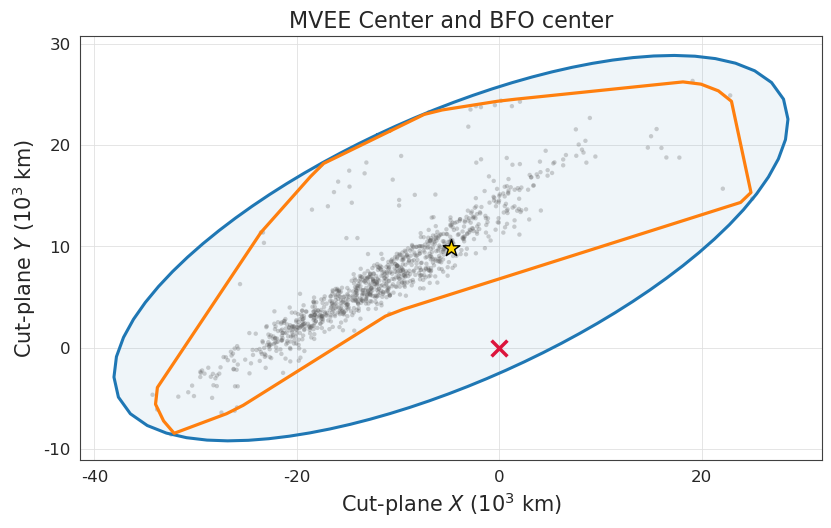

In [74]:
# Single-slice polygon-over-MVEE figure. Change SINGLE_SLICE_INDEX only.
SINGLE_SLICE_INDEX = 179

slice_index = SINGLE_SLICE_INDEX
if not isinstance(slice_index, int):
    raise TypeError('SINGLE_SLICE_INDEX must be an integer')
if not 0 <= slice_index < min(len(ellipse_slices), len(polygon_slices)):
    raise IndexError(f'SINGLE_SLICE_INDEX must be between 0 and {min(len(ellipse_slices), len(polygon_slices)) - 1}')

ellipse = ellipse_slices[slice_index]
polygon = polygon_slices[slice_index]
if str(ellipse['time']) != str(polygon['time']):
    raise ValueError(f'Time mismatch between tubes at slice {slice_index}')
cache_matches = np.flatnonzero(overlay_cutplane_indices == slice_index)
if len(cache_matches) != 1:
    raise ValueError(f'Expected one cache row for slice {slice_index}, found {len(cache_matches)}')
cache_index = int(cache_matches[0])
positions = overlay_positions_km[cache_index]
velocities = overlay_velocities_km_s[cache_index]
finite_states = np.all(np.isfinite(positions), axis=1) & np.all(np.isfinite(velocities), axis=1)

bfo_data = ellipse['bfo-center']
bfo_center_km = np.array([bfo_data['x'], bfo_data['y'], bfo_data['z']], dtype=float) / 1000.0
single_intersections_km, _, single_normal = intersect_variants_with_plane(
    bfo_center_km, positions[finite_states], velocities[finite_states]
)
valid = np.all(np.isfinite(single_intersections_km), axis=1)
single_intersections_km = single_intersections_km[valid]
single_rotation = tube_util.calcRotationMatrix(single_normal, np.array([0.0, 0.0, 1.0]))
single_variants_2d_km = (single_rotation @ (single_intersections_km - bfo_center_km).T).T[:, :2]

def boundary_in_bfo_plane(record):
    points_3d_km = np.array(
        [[point['x'], point['y'], point['z']] for point in record['points']], dtype=float
    ) / 1000.0
    return (single_rotation @ (points_3d_km - bfo_center_km).T).T[:, :2]

single_ellipse_2d_km = boundary_in_bfo_plane(ellipse)
single_polygon_2d_km = boundary_in_bfo_plane(polygon)
ellipse_closed = np.vstack([single_ellipse_2d_km, single_ellipse_2d_km[0]])
polygon_closed = np.vstack([single_polygon_2d_km, single_polygon_2d_km[0]])
fitted_data = ellipse['center']
fitted_center_km = np.array([fitted_data['x'], fitted_data['y'], fitted_data['z']], dtype=float) / 1000.0
fitted_center_2d_km = (single_rotation @ (fitted_center_km - bfo_center_km))[:2]

from matplotlib.ticker import FuncFormatter, MultipleLocator
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    context='paper',
    style='whitegrid',
    font_scale=1.0,
    rc={
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'axes.edgecolor': '0.25',
        'axes.linewidth': 0.8,
        'grid.color': '0.88',
        'grid.linewidth': 0.6,
        'grid.alpha': 1.0,

        # Font sizes
        'font.size': 14,
        'axes.titlesize': 16,
        'axes.labelsize': 15,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'legend.fontsize': 12,

        'xtick.direction': 'out',
        'ytick.direction': 'out',
        'xtick.major.size': 3.5,
        'ytick.major.size': 3.5,
        'legend.frameon': True,
    }
)

fig, axis = plt.subplots(figsize=(8.2, 7.2), constrained_layout=True)

axis.fill(
    ellipse_closed[:, 0],
    ellipse_closed[:, 1],
    color='tab:blue',
    alpha=0.07
)
axis.plot(
    ellipse_closed[:, 0],
    ellipse_closed[:, 1],
    color='tab:blue',
    linewidth=2.2,
    label='MVEE'
)
axis.scatter(
    single_variants_2d_km[:, 0],
    single_variants_2d_km[:, 1],
    s=10,
    color='0.35',
    alpha=0.28,
    edgecolors='none'
)
axis.plot(
    polygon_closed[:, 0],
    polygon_closed[:, 1],
    color='tab:orange',
    linewidth=2.3,
    label='Alpha shape'
)

axis.scatter(
    fitted_center_2d_km[0],
    fitted_center_2d_km[1],
    s=160,
    marker='*',
    facecolor='gold',
    edgecolor='black',
    linewidth=1.0,
    label='MVEE center',
    zorder=5
)
axis.scatter(
    0.0,
    0.0,
    s=130,
    marker='x',
    color='crimson',
    linewidth=2.5,
    label='BFO center',
    zorder=6
)

# Display coordinates in units of 10^3 km without modifying the data.
thousands_formatter = FuncFormatter(
    lambda value, position: f'{value / 1000:g}'
)

axis.xaxis.set_major_formatter(thousands_formatter)
axis.yaxis.set_major_formatter(thousands_formatter)

# Tick spacing remains specified in the original kilometer units.
axis.xaxis.set_major_locator(MultipleLocator(20_000))
axis.yaxis.set_major_locator(MultipleLocator(10_000))

axis.set_xlabel(r'Cut-plane $X$ ($10^3$ km)')
axis.set_ylabel(r'Cut-plane $Y$ ($10^3$ km)')

axis.set_title(
    f'MVEE Center and BFO center'
)
axis.set_aspect('equal', adjustable='box')
# axis.grid(alpha=0.2)
# legend = axis.legend(
#     loc='upper left',
#     frameon=True,
#     facecolor='white',
#     edgecolor='0.82',
#     framealpha=0.85,
#     fancybox=False,
#     borderpad=0.4,
#     labelspacing=0.3,
#     handlelength=1.8
# )
# legend.get_frame().set_linewidth(0.7)

# sns.despine(ax=axis)
plt.show()

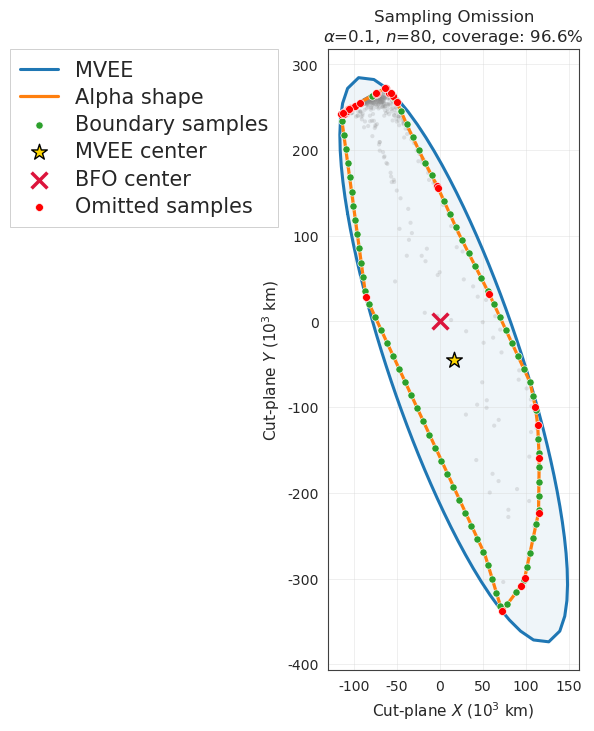

In [73]:
# Show variant intersections lost when the full alpha boundary is sampled.
# Change OMISSION_SLICE_INDEX independently of the preceding figure.
OMISSION_SLICE_INDEX = 190

from shapely.geometry import Point, Polygon
from shapely.prepared import prep

if not isinstance(OMISSION_SLICE_INDEX, int):
    raise TypeError('OMISSION_SLICE_INDEX must be an integer')
if not 0 <= OMISSION_SLICE_INDEX < len(ellipse_slices):
    raise IndexError(f'OMISSION_SLICE_INDEX must be between 0 and {len(ellipse_slices) - 1}')
metadata_path = object_directory / 'tube_2004_MN4_polygon_all_metadata.txt'
metadata_values = {}
with metadata_path.open('r', encoding='utf-8') as metadata_file:
    for line in metadata_file:
        if ':' in line:
            key, value = line.split(':', 1)
            metadata_values[key.strip()] = value.strip()
if 'selected_global_alpha' not in metadata_values:
    raise KeyError(f'{metadata_path} has no selected_global_alpha entry')
omission_alpha = float(metadata_values['selected_global_alpha'])
omission_sample_count = len(polygon_slices[OMISSION_SLICE_INDEX]['points'])
if omission_sample_count < 3:
    raise ValueError(f'Slice {OMISSION_SLICE_INDEX} has fewer than three boundary samples')
cache_matches = np.flatnonzero(overlay_cutplane_indices == OMISSION_SLICE_INDEX)
if len(cache_matches) != 1:
    raise ValueError(f'Expected one cache row for slice {OMISSION_SLICE_INDEX}, found {len(cache_matches)}')
cache_index = int(cache_matches[0])
positions = overlay_positions_km[cache_index]
velocities = overlay_velocities_km_s[cache_index]
finite_states = np.all(np.isfinite(positions), axis=1) & np.all(np.isfinite(velocities), axis=1)
omission_ellipse = ellipse_slices[OMISSION_SLICE_INDEX]
bfo_data = omission_ellipse['bfo-center']
omission_bfo_center_km = np.array(
    [bfo_data['x'], bfo_data['y'], bfo_data['z']], dtype=float
) / 1000.0
omission_intersections_km, _, omission_normal = intersect_variants_with_plane(
    omission_bfo_center_km, positions[finite_states], velocities[finite_states]
)
valid = np.all(np.isfinite(omission_intersections_km), axis=1)
omission_intersections_km = omission_intersections_km[valid]
omission_rotation = tube_util.calcRotationMatrix(
    omission_normal, np.array([0.0, 0.0, 1.0])
)
omission_variants_2d_km = (
    omission_rotation @ (omission_intersections_km - omission_bfo_center_km).T
).T[:, :2]
ellipse_3d_km = np.array(
    [[point['x'], point['y'], point['z']] for point in omission_ellipse['points']],
    dtype=float,
) / 1000.0
ellipse_2d_km = (
    omission_rotation @ (ellipse_3d_km - omission_bfo_center_km).T
).T[:, :2]
ellipse_closed = np.vstack([ellipse_2d_km, ellipse_2d_km[0]])

# Project the fitted MVEE center into the same cut-plane coordinates.
fitted_data = omission_ellipse['center']
omission_fitted_center_km = np.array(
    [fitted_data['x'], fitted_data['y'], fitted_data['z']],
    dtype=float,
) / 1000.0

omission_fitted_center_2d_km = (
    omission_rotation
    @ (omission_fitted_center_km - omission_bfo_center_km)
)[:2]

alpha_result = calculate_alpha_shape(omission_variants_2d_km, alpha=omission_alpha)
sampled_boundary = sample_alpha_shape_boundary(
    alpha_result, omission_sample_count, omission_normal
)
full_closed = np.vstack([alpha_result.boundary_2d, alpha_result.boundary_2d[0]])

span_km = float(np.ptp(sampled_boundary, axis=0).max())
tolerance_km = max(
    span_km * polygon_generation.POLYGON_COVERAGE_RELATIVE_TOLERANCE,
    np.finfo(float).eps * max(1.0, span_km) * 32.0,
)
full_polygon = prep(Polygon(alpha_result.boundary_2d).buffer(tolerance_km))
sampled_polygon = prep(Polygon(sampled_boundary).buffer(tolerance_km))
full_covered = np.fromiter(
    (full_polygon.covers(Point(point)) for point in omission_variants_2d_km),
    dtype=bool, count=len(omission_variants_2d_km),
)
sampled_covered = np.fromiter(
    (sampled_polygon.covers(Point(point)) for point in omission_variants_2d_km),
    dtype=bool, count=len(omission_variants_2d_km),
)
omitted = full_covered & ~sampled_covered

from matplotlib.ticker import FuncFormatter, MultipleLocator

sns.set_theme(
    context='paper',
    style='whitegrid',
    font_scale=1.0,
    rc={
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'axes.edgecolor': '0.25',
        'axes.linewidth': 0.8,
        'grid.color': '0.88',
        'grid.linewidth': 0.6,
        'grid.alpha': 1.0,

        # Font sizes
        'font.size': 10,
        'axes.titlesize': 12,
        'axes.labelsize': 11,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
        'legend.fontsize': 15,

        'xtick.direction': 'out',
        'ytick.direction': 'out',
        'xtick.major.size': 3.5,
        'ytick.major.size': 3.5,
        'legend.frameon': True,
    }
)

fig, axis = plt.subplots(
    figsize=(10.5, 7.2),
    constrained_layout=True
)

# Projected trajectory variants
axis.scatter(
    omission_variants_2d_km[:, 0],
    omission_variants_2d_km[:, 1],
    s=9,
    color='0.55',
    alpha=0.22,
    edgecolors='none',
    # label='Variants',
    rasterized=True,
    zorder=1
)

# MVEE with a light-blue fill
axis.fill(
    ellipse_closed[:, 0],
    ellipse_closed[:, 1],
    color='tab:blue',
    alpha=0.07,
    zorder=0
)
axis.plot(
    ellipse_closed[:, 0],
    ellipse_closed[:, 1],
    color='tab:blue',
    linewidth=2.2,
    label='MVEE',
    zorder=2
)

# Full alpha-shape boundary
axis.plot(
    full_closed[:, 0],
    full_closed[:, 1],
    color='tab:orange',
    linewidth=2.3,
    label=r'Alpha shape',
    zorder=3
)

# Sampled alpha-shape boundary points
axis.scatter(
    sampled_boundary[:, 0],
    sampled_boundary[:, 1],
    s=27,
    color='tab:green',
    edgecolor='white',
    linewidth=0.45,
    label='Boundary samples',
    zorder=5
)

# MVEE center
axis.scatter(
    omission_fitted_center_2d_km[0],
    omission_fitted_center_2d_km[1],
    s=140,
    marker='*',
    facecolor='gold',
    edgecolor='black',
    linewidth=1.0,
    label='MVEE center',
    zorder=7
)

# The BFO center is the origin because the plane coordinates are
# centered on the best-fitting orbit.
axis.scatter(
    0.0,
    0.0,
    s=130,
    marker='x',
    color='crimson',
    linewidth=2.5,
    label='BFO center',
    zorder=6
)

# Variants covered by the full alpha shape but omitted after sampling
axis.scatter(
    omission_variants_2d_km[omitted, 0],
    omission_variants_2d_km[omitted, 1],
    s=32,
    color='red',
    edgecolor='white',
    linewidth=0.45,
    label=f'Omitted samples',
    zorder=6
)

# Display coordinates in units of 10^3 km.
thousands_formatter = FuncFormatter(
    lambda value, position: f'{value / 1000:g}'
)

axis.xaxis.set_major_formatter(thousands_formatter)
axis.yaxis.set_major_formatter(thousands_formatter)

# Tick intervals remain specified in kilometers.
axis.xaxis.set_major_locator(MultipleLocator(50_000))
axis.yaxis.set_major_locator(MultipleLocator(100_000))

axis.set_xlabel(r'Cut-plane $X$ ($10^3$ km)')
axis.set_ylabel(r'Cut-plane $Y$ ($10^3$ km)')

axis.set_title(
    f'Sampling Omission\n'
    f'$\\alpha$={omission_alpha:g}, '
    f'$n$={omission_sample_count}, '
    f'coverage: {sampled_covered.mean():.1%}'
)

axis.set_aspect('equal', adjustable='box')

axis.grid(
    color='0.85',
    linewidth=0.6,
    alpha=0.5
)

legend = axis.legend(
    loc='upper right',
    bbox_to_anchor=(-0.2, 1.0),
    borderaxespad=0.0,
    frameon=True,
    facecolor='white',
    edgecolor='0.80',
    framealpha=0.92,
    fancybox=False,
    borderpad=0.5,
    labelspacing=0.35,
    handlelength=1.8
)
legend.get_frame().set_linewidth(0.7)

# sns.despine(ax=axis)

plt.show()


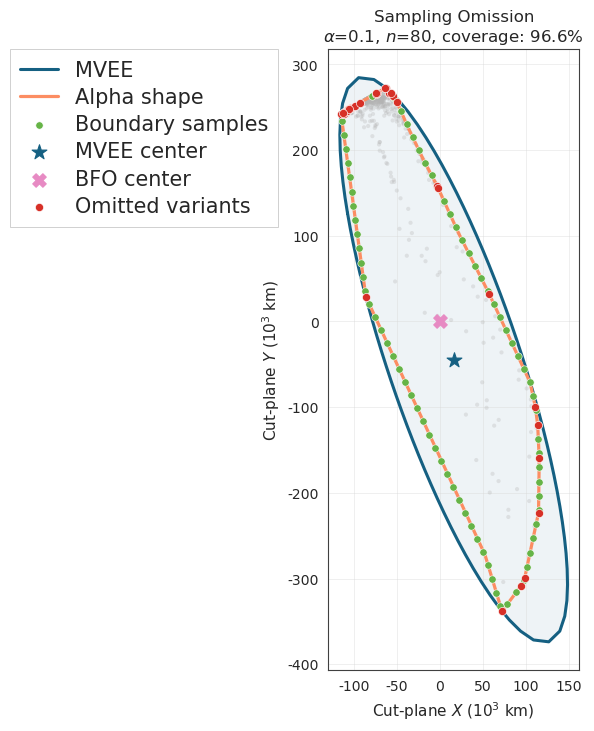

In [101]:
# Show variant intersections lost when the full alpha boundary is sampled.
# Change OMISSION_SLICE_INDEX independently of the preceding figure.
OMISSION_SLICE_INDEX = 190

from shapely.geometry import Point, Polygon
from shapely.prepared import prep

if not isinstance(OMISSION_SLICE_INDEX, int):
    raise TypeError('OMISSION_SLICE_INDEX must be an integer')
if not 0 <= OMISSION_SLICE_INDEX < len(ellipse_slices):
    raise IndexError(f'OMISSION_SLICE_INDEX must be between 0 and {len(ellipse_slices) - 1}')
metadata_path = object_directory / 'tube_2004_MN4_polygon_all_metadata.txt'
metadata_values = {}
with metadata_path.open('r', encoding='utf-8') as metadata_file:
    for line in metadata_file:
        if ':' in line:
            key, value = line.split(':', 1)
            metadata_values[key.strip()] = value.strip()
if 'selected_global_alpha' not in metadata_values:
    raise KeyError(f'{metadata_path} has no selected_global_alpha entry')
omission_alpha = float(metadata_values['selected_global_alpha'])
omission_sample_count = len(polygon_slices[OMISSION_SLICE_INDEX]['points'])
if omission_sample_count < 3:
    raise ValueError(f'Slice {OMISSION_SLICE_INDEX} has fewer than three boundary samples')
cache_matches = np.flatnonzero(overlay_cutplane_indices == OMISSION_SLICE_INDEX)
if len(cache_matches) != 1:
    raise ValueError(f'Expected one cache row for slice {OMISSION_SLICE_INDEX}, found {len(cache_matches)}')
cache_index = int(cache_matches[0])
positions = overlay_positions_km[cache_index]
velocities = overlay_velocities_km_s[cache_index]
finite_states = np.all(np.isfinite(positions), axis=1) & np.all(np.isfinite(velocities), axis=1)
omission_ellipse = ellipse_slices[OMISSION_SLICE_INDEX]
bfo_data = omission_ellipse['bfo-center']
omission_bfo_center_km = np.array(
    [bfo_data['x'], bfo_data['y'], bfo_data['z']], dtype=float
) / 1000.0
omission_intersections_km, _, omission_normal = intersect_variants_with_plane(
    omission_bfo_center_km, positions[finite_states], velocities[finite_states]
)
valid = np.all(np.isfinite(omission_intersections_km), axis=1)
omission_intersections_km = omission_intersections_km[valid]
omission_rotation = tube_util.calcRotationMatrix(
    omission_normal, np.array([0.0, 0.0, 1.0])
)
omission_variants_2d_km = (
    omission_rotation @ (omission_intersections_km - omission_bfo_center_km).T
).T[:, :2]
ellipse_3d_km = np.array(
    [[point['x'], point['y'], point['z']] for point in omission_ellipse['points']],
    dtype=float,
) / 1000.0
ellipse_2d_km = (
    omission_rotation @ (ellipse_3d_km - omission_bfo_center_km).T
).T[:, :2]
ellipse_closed = np.vstack([ellipse_2d_km, ellipse_2d_km[0]])

# Project the fitted MVEE center into the same cut-plane coordinates.
fitted_data = omission_ellipse['center']
omission_fitted_center_km = np.array(
    [fitted_data['x'], fitted_data['y'], fitted_data['z']],
    dtype=float,
) / 1000.0

omission_fitted_center_2d_km = (
    omission_rotation
    @ (omission_fitted_center_km - omission_bfo_center_km)
)[:2]

alpha_result = calculate_alpha_shape(omission_variants_2d_km, alpha=omission_alpha)
sampled_boundary = sample_alpha_shape_boundary(
    alpha_result, omission_sample_count, omission_normal
)
full_closed = np.vstack([alpha_result.boundary_2d, alpha_result.boundary_2d[0]])

span_km = float(np.ptp(sampled_boundary, axis=0).max())
tolerance_km = max(
    span_km * polygon_generation.POLYGON_COVERAGE_RELATIVE_TOLERANCE,
    np.finfo(float).eps * max(1.0, span_km) * 32.0,
)
full_polygon = prep(Polygon(alpha_result.boundary_2d).buffer(tolerance_km))
sampled_polygon = prep(Polygon(sampled_boundary).buffer(tolerance_km))
full_covered = np.fromiter(
    (full_polygon.covers(Point(point)) for point in omission_variants_2d_km),
    dtype=bool, count=len(omission_variants_2d_km),
)
sampled_covered = np.fromiter(
    (sampled_polygon.covers(Point(point)) for point in omission_variants_2d_km),
    dtype=bool, count=len(omission_variants_2d_km),
)
omitted = full_covered & ~sampled_covered

from matplotlib.ticker import FuncFormatter, MultipleLocator

PAPER_TEAL   = '#156082'
PAPER_CORAL  = '#FC8D62'
PAPER_YELLOW = '#FFD92F'
PAPER_GREEN  = '#66B447'
PAPER_PINK   = '#E78AC3'
PAPER_RED    = '#D73027'
PAPER_GRAY   = '#B3B3B3'

MVEE_COLOR = PAPER_TEAL
ALPHA_COLOR = PAPER_CORAL
BOUNDARY_SAMPLE_COLOR = PAPER_GREEN
MVEE_CENTER_COLOR = PAPER_TEAL
BFO_CENTER_COLOR = PAPER_PINK
OMITTED_COLOR = PAPER_RED
VARIANT_COLOR = PAPER_GRAY

sns.set_theme(
    context='paper',
    style='whitegrid',
    font_scale=1.0,
    rc={
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'axes.edgecolor': '0.25',
        'axes.linewidth': 0.8,
        'grid.color': '0.88',
        'grid.linewidth': 0.6,
        'grid.alpha': 1.0,

        # Font sizes
        'font.size': 10,
        'axes.titlesize': 12,
        'axes.labelsize': 11,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
        'legend.fontsize': 15,

        'xtick.direction': 'out',
        'ytick.direction': 'out',
        'xtick.major.size': 3.5,
        'ytick.major.size': 3.5,
        'legend.frameon': True,
    }
)

fig, axis = plt.subplots(
    figsize=(10.5, 7.2),
    constrained_layout=True
)

# Projected trajectory variants
axis.scatter(
    omission_variants_2d_km[:, 0],
    omission_variants_2d_km[:, 1],
    s=9,
    color=VARIANT_COLOR,
    alpha=0.30,
    edgecolors='none',
    rasterized=True,
    zorder=1
)
# MVEE
axis.fill(
    ellipse_closed[:, 0],
    ellipse_closed[:, 1],
    color=MVEE_COLOR,
    alpha=0.07,
    zorder=0
)
axis.plot(
    ellipse_closed[:, 0],
    ellipse_closed[:, 1],
    color=MVEE_COLOR,
    linewidth=2.2,
    label='MVEE',
    zorder=2
)

# Alpha-shape boundary
axis.plot(
    full_closed[:, 0],
    full_closed[:, 1],
    color=ALPHA_COLOR,
    linewidth=2.3,
    label='Alpha shape',
    zorder=3
)

# Boundary samples
axis.scatter(
    sampled_boundary[:, 0],
    sampled_boundary[:, 1],
    s=28,
    color=BOUNDARY_SAMPLE_COLOR,
    edgecolor='white',
    linewidth=0.4,
    label='Boundary samples',
    zorder=5
)

# MVEE center
axis.scatter(
    omission_fitted_center_2d_km[0],
    omission_fitted_center_2d_km[1],
    s=125,
    marker='*',
    color=MVEE_CENTER_COLOR,
    # edgecolor='white',
    # linewidth=0.6,
    label='MVEE center',
    zorder=7
)

# Best-fit-orbit center
axis.scatter(
    0.0,
    0.0,
    s=95,
    marker='X',
    color=BFO_CENTER_COLOR,
    # edgecolor='white',
    # linewidth=0.6,
    label='BFO center',
    zorder=7
)

# Omitted variants
axis.scatter(
    omission_variants_2d_km[omitted, 0],
    omission_variants_2d_km[omitted, 1],
    s=34,
    color=OMITTED_COLOR,
    edgecolor='white',
    linewidth=0.45,
    label='Omitted variants',
    zorder=8
)

# Display coordinates in units of 10^3 km.
thousands_formatter = FuncFormatter(
    lambda value, position: f'{value / 1000:g}'
)

axis.xaxis.set_major_formatter(thousands_formatter)
axis.yaxis.set_major_formatter(thousands_formatter)

# Tick intervals remain specified in kilometers.
axis.xaxis.set_major_locator(MultipleLocator(50_000))
axis.yaxis.set_major_locator(MultipleLocator(100_000))

axis.set_xlabel(r'Cut-plane $X$ ($10^3$ km)')
axis.set_ylabel(r'Cut-plane $Y$ ($10^3$ km)')

axis.set_title(
    f'Sampling Omission\n'
    f'$\\alpha$={omission_alpha:g}, '
    f'$n$={omission_sample_count}, '
    f'coverage: {sampled_covered.mean():.1%}'
)

axis.set_aspect('equal', adjustable='box')

axis.grid(
    color='0.85',
    linewidth=0.6,
    alpha=0.5
)

legend = axis.legend(
    loc='upper right',
    bbox_to_anchor=(-0.2, 1.0),
    borderaxespad=0.0,
    frameon=True,
    facecolor='white',
    edgecolor='0.80',
    framealpha=0.92,
    fancybox=False,
    borderpad=0.5,
    labelspacing=0.35,
    handlelength=1.8
)
legend.get_frame().set_linewidth(0.7)

# sns.despine(ax=axis)

plt.show()


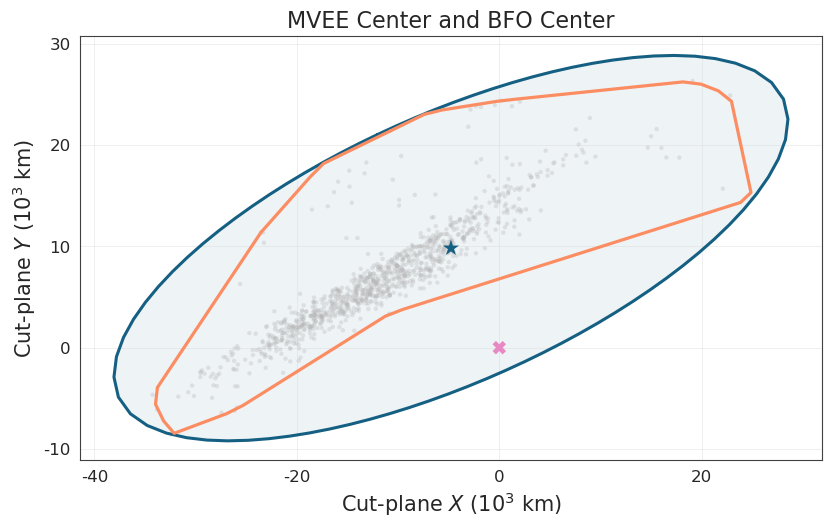

In [104]:
# Single-slice polygon-over-MVEE figure. Change SINGLE_SLICE_INDEX only.
SINGLE_SLICE_INDEX = 179

slice_index = SINGLE_SLICE_INDEX

if not isinstance(slice_index, int):
    raise TypeError('SINGLE_SLICE_INDEX must be an integer')

if not 0 <= slice_index < min(len(ellipse_slices), len(polygon_slices)):
    raise IndexError(
        f'SINGLE_SLICE_INDEX must be between 0 and '
        f'{min(len(ellipse_slices), len(polygon_slices)) - 1}'
    )

ellipse = ellipse_slices[slice_index]
polygon = polygon_slices[slice_index]

if str(ellipse['time']) != str(polygon['time']):
    raise ValueError(
        f'Time mismatch between tubes at slice {slice_index}'
    )

cache_matches = np.flatnonzero(
    overlay_cutplane_indices == slice_index
)

if len(cache_matches) != 1:
    raise ValueError(
        f'Expected one cache row for slice {slice_index}, '
        f'found {len(cache_matches)}'
    )

cache_index = int(cache_matches[0])
positions = overlay_positions_km[cache_index]
velocities = overlay_velocities_km_s[cache_index]

finite_states = (
    np.all(np.isfinite(positions), axis=1)
    & np.all(np.isfinite(velocities), axis=1)
)

bfo_data = ellipse['bfo-center']
bfo_center_km = np.array(
    [bfo_data['x'], bfo_data['y'], bfo_data['z']],
    dtype=float,
) / 1000.0

single_intersections_km, _, single_normal = (
    intersect_variants_with_plane(
        bfo_center_km,
        positions[finite_states],
        velocities[finite_states],
    )
)

valid = np.all(
    np.isfinite(single_intersections_km),
    axis=1,
)
single_intersections_km = single_intersections_km[valid]

single_rotation = tube_util.calcRotationMatrix(
    single_normal,
    np.array([0.0, 0.0, 1.0]),
)

single_variants_2d_km = (
    single_rotation
    @ (single_intersections_km - bfo_center_km).T
).T[:, :2]


def boundary_in_bfo_plane(record):
    points_3d_km = np.array(
        [
            [point['x'], point['y'], point['z']]
            for point in record['points']
        ],
        dtype=float,
    ) / 1000.0

    return (
        single_rotation
        @ (points_3d_km - bfo_center_km).T
    ).T[:, :2]


single_ellipse_2d_km = boundary_in_bfo_plane(ellipse)
single_polygon_2d_km = boundary_in_bfo_plane(polygon)

ellipse_closed = np.vstack([
    single_ellipse_2d_km,
    single_ellipse_2d_km[0],
])

polygon_closed = np.vstack([
    single_polygon_2d_km,
    single_polygon_2d_km[0],
])

# Project the fitted MVEE center into the cut plane.
fitted_data = ellipse['center']
fitted_center_km = np.array(
    [fitted_data['x'], fitted_data['y'], fitted_data['z']],
    dtype=float,
) / 1000.0

fitted_center_2d_km = (
    single_rotation
    @ (fitted_center_km - bfo_center_km)
)[:2]


from matplotlib.ticker import FuncFormatter, MultipleLocator
import matplotlib.pyplot as plt
import seaborn as sns


# Colors used in the preceding paper figures.
PAPER_TEAL   = '#156082'
PAPER_CORAL  = '#FC8D62'
PAPER_YELLOW = '#FFD92F'
PAPER_GREEN  = '#66B447'
PAPER_PINK   = '#E78AC3'
PAPER_RED    = '#D73027'
PAPER_GRAY   = '#B3B3B3'

MVEE_COLOR = PAPER_TEAL
ALPHA_COLOR = PAPER_CORAL
MVEE_CENTER_COLOR = PAPER_TEAL
BFO_CENTER_COLOR = PAPER_PINK
VARIANT_COLOR = PAPER_GRAY


sns.set_theme(
    context='paper',
    style='whitegrid',
    font_scale=1.0,
    rc={
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'axes.edgecolor': '0.25',
        'axes.linewidth': 0.8,
        'grid.color': '0.88',
        'grid.linewidth': 0.6,
        'grid.alpha': 1.0,

        # Font sizes
        'font.size': 14,
        'axes.titlesize': 16,
        'axes.labelsize': 15,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'legend.fontsize': 12,

        'xtick.direction': 'out',
        'ytick.direction': 'out',
        'xtick.major.size': 3.5,
        'ytick.major.size': 3.5,
        'legend.frameon': True,
    },
)


fig, axis = plt.subplots(
    figsize=(8.2, 7.2),
    constrained_layout=True,
)

# Projected trajectory variants
axis.scatter(
    single_variants_2d_km[:, 0],
    single_variants_2d_km[:, 1],
    s=10,
    color=VARIANT_COLOR,
    alpha=0.30,
    edgecolors='none',
    rasterized=True,
    zorder=1,
)

# MVEE with a light teal fill
axis.fill(
    ellipse_closed[:, 0],
    ellipse_closed[:, 1],
    color=MVEE_COLOR,
    alpha=0.07,
    zorder=0,
)
axis.plot(
    ellipse_closed[:, 0],
    ellipse_closed[:, 1],
    color=MVEE_COLOR,
    linewidth=2.2,
    label='MVEE',
    zorder=2,
)

# Sampled alpha-shape boundary
axis.plot(
    polygon_closed[:, 0],
    polygon_closed[:, 1],
    color=ALPHA_COLOR,
    linewidth=2.3,
    label='Alpha-shape boundary',
    zorder=3,
)

# MVEE center
axis.scatter(
    fitted_center_2d_km[0],
    fitted_center_2d_km[1],
    s=150,
    marker='*',
    color=MVEE_CENTER_COLOR,
    edgecolors='none',
    label='MVEE center',
    zorder=7,
)

# BFO center
axis.scatter(
    0.0,
    0.0,
    s=95,
    marker='X',
    color=BFO_CENTER_COLOR,
    edgecolors='none',
    label='BFO center',
    zorder=7,
)


# Display coordinates in units of 10^3 km without modifying the data.
thousands_formatter = FuncFormatter(
    lambda value, position: f'{value / 1000:g}'
)

axis.xaxis.set_major_formatter(thousands_formatter)
axis.yaxis.set_major_formatter(thousands_formatter)

# Tick spacing remains specified in kilometers.
axis.xaxis.set_major_locator(MultipleLocator(20_000))
axis.yaxis.set_major_locator(MultipleLocator(10_000))

axis.set_xlabel(r'Cut-plane $X$ ($10^3$ km)')
axis.set_ylabel(r'Cut-plane $Y$ ($10^3$ km)')

axis.set_title('MVEE Center and BFO Center')

axis.set_aspect(
    'equal',
    adjustable='box',
)

axis.grid(
    color='0.85',
    linewidth=0.6,
    alpha=0.5,
)

# legend = axis.legend(
#     loc='upper left',
#     frameon=True,
#     facecolor='white',
#     edgecolor='0.80',
#     framealpha=0.92,
#     fancybox=False,
#     borderpad=0.5,
#     labelspacing=0.35,
#     handlelength=1.8,
# )
# legend.get_frame().set_linewidth(0.7)

plt.show()